<a href="https://colab.research.google.com/github/dpnolan/pandemic/blob/main/CmdStanPy1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

In [1]:
# Install package CmdStanPy
!pip install --upgrade cmdstanpy

In [1]:
# Load packages used in this notebook
import os
import json
import shutil
import urllib.request
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import arviz as az

In [2]:
# Install pre-built CmdStan binary
# (faster than compiling from source via install_cmdstan() function)
tgz_file = 'colab-cmdstan-2.23.0.tar.gz'
tgz_url = 'https://github.com/stan-dev/cmdstan/releases/download/v2.23.0/colab-cmdstan-2.23.0.tar.gz'
if not os.path.exists(tgz_file):
    urllib.request.urlretrieve(tgz_url, tgz_file)
    shutil.unpack_archive(tgz_file)

In [3]:
# Specify CmdStan location via environment variable
os.environ['CMDSTAN'] = '/content/cmdstan-2.23.0'
# Check CmdStan path
from cmdstanpy import CmdStanModel, cmdstan_path
cmdstan_path()

'/content/cmdstan-2.23.0'

In [5]:
!ls -al

total 54848
drwxr-xr-x  1 root root     4096 Nov 11 19:17 .
drwxr-xr-x  1 root root     4096 Nov 11 19:05 ..
drwxrwxrwx 11 1000 1000     4096 Nov 11 19:17 cmdstan-2.23.0
-rw-r--r--  1 root root 56124352 Nov 11 19:07 colab-cmdstan-2.23.0.tar.gz
drwxr-xr-x  4 root root     4096 Nov  7 14:30 .config
drwx------  5 root root     4096 Nov 11 19:06 drive
drwxr-xr-x  2 root root     4096 Nov 11 19:12 .ipynb_checkpoints
drwxr-xr-x  1 root root     4096 Nov  7 14:30 sample_data
drwxr-xr-x  2 root root     4096 Nov 11 19:13 WSL


In [6]:
bernoulli_stan = os.path.join(cmdstan_path(), 'examples', 'bernoulli', 'bernoulli1.stan')
with open(bernoulli_stan, 'r') as fd:
        print('\n'.join(fd.read().splitlines()))

data { 
  int<lower=0> N; 
  array[N] int<lower=0,upper=1> y;

} 
parameters {
  real<lower=0,upper=1> theta;
} 
model {
  theta ~ beta(1,1);  // uniform prior on interval 0,1
  y ~ bernoulli(theta);
}


In [7]:
bernoulli_data = os.path.join(cmdstan_path(), 'examples', 'bernoulli', 'bernoulli.data.json')
with open(bernoulli_data, 'r') as fd:
        print('\n'.join(fd.read().splitlines()))

{
    "N" : 10,
    "y" : [0,1,0,0,0,0,0,0,0,1]
}


In [8]:
print(os.getcwd())
print(os.listdir())

os.chdir("/content/cmdstan-2.23.0/examples/bernoulli")
#os.chdir("/content/")

print(os.getcwd())
print(os.listdir())

/content
['.config', '.ipynb_checkpoints', 'cmdstan-2.23.0', 'WSL', 'colab-cmdstan-2.23.0.tar.gz', 'drive', 'sample_data']
/content/cmdstan-2.23.0/examples/bernoulli
['bernoulli.data.R', 'bernoulli.o', 'bernoulli.stan', 'bernoulli.hpp', 'bernoulli.d', 'bernoulli.data.json', 'bernoulli', '.gitignore', 'bernoulli1.stan']


In [9]:
# Install/upgrade CmdStanPy
!pip -q install -U cmdstanpy

# Install a recent CmdStan (downloads & builds under ~/.cmdstan)
from cmdstanpy import install_cmdstan, set_cmdstan_path, cmdstan_path, cmdstan_version
import os

# Ensure no stale hardcoded path is set
os.environ.pop("CMDSTAN", None)

# Install a modern CmdStan (omit version= to get latest)
install_cmdstan(version="2.35.0")

# Point CmdStanPy at the new install
set_cmdstan_path(cmdstan_path())

# Sanity check
import cmdstanpy
print("CmdStanPy:", cmdstanpy.__version__)
print("CmdStan:", cmdstan_version(), "at", cmdstan_path())



CmdStan install directory: /root/.cmdstan
Installing CmdStan version: 2.35.0
Download successful, file: /tmp/tmppxgh_zsd
Extracting distribution
Unpacked download as cmdstan-2.35.0
Building version cmdstan-2.35.0, may take several minutes, depending on your system.
Installed cmdstan-2.35.0
Test model compilation
CmdStanPy: 1.3.0
CmdStan: (2, 35) at /root/.cmdstan/cmdstan-2.35.0


In [12]:
# Run CmdStanPy Hello, World! example
from cmdstanpy import cmdstan_path, CmdStanModel

bernoulli_model = CmdStanModel(stan_file=bernoulli_stan)
bern_fit = bernoulli_model.sample(data=bernoulli_data, seed=123)

chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

In [13]:
# Print a summary of the posterior sample
bern_fit.summary()

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
lp__,-7.295900,0.019504,0.805431,-8.825840,-7.005880,-6.750600,1705.28,10150.50,1.00062
theta,0.257094,0.003555,0.124199,0.079213,0.242757,0.485756,1220.34,7263.91,1.00166


##School Example

In [10]:
print(os.getcwd())
print(os.listdir())

os.chdir("/content/")
#os.chdir("/content/")

# Verify
print(os.getcwd())
print(os.listdir())

/content/cmdstan-2.23.0/examples/bernoulli
['bernoulli.data.R', 'bernoulli.o', 'bernoulli.stan', 'bernoulli.hpp', 'bernoulli.d', 'bernoulli.data.json', 'bernoulli', '.gitignore', 'bernoulli1.stan']
/content
['.config', '.ipynb_checkpoints', 'cmdstan-2.23.0', 'WSL', 'colab-cmdstan-2.23.0.tar.gz', 'drive', 'data', 'stan', 'sample_data']


In [20]:
csv_path = Path("data/influenza_england_1978_school.csv")

In [12]:
df = pd.read_csv(csv_path)

In [13]:
df

,Unnamed: 0,date,in_bed,convalescent
0,1,22/01/1978,3,0
1,2,23/01/1978,8,0
2,3,24/01/1978,26,0
3,4,25/01/1978,76,0
4,5,26/01/1978,225,9
5,6,27/01/1978,298,17
6,7,28/01/1978,258,105
7,8,29/01/1978,233,162
8,9,30/01/1978,189,176
9,10,31/01/1978,128,166


In [15]:
cases = df["in_bed"].astype(int).to_numpy()
n_days = len(cases)

In [16]:
# --- Time axis used by Stan ODE block ---
t0 = 0.0
# Typical choice: one time unit per row. Stan expects strictly increasing ts:
ts = np.arange(1, n_days + 1, dtype=float)


In [17]:
# --- Population size (N) and initial state y0 ---
N = 763

# Initial conditions [S0, I0, R0]; common choice starts with 1 infected, 0 recovered.
y0 = np.array([N - 1, 1, 0], dtype=float)


In [18]:
# --- Build Stan data list (must match the Stan file's data block) ---
stan_data = {
    "n_days": int(n_days),
    "y0": y0.astype(float),
    "t0": float(t0),
    "ts": ts.astype(float),
    "N": int(N),
    "cases": cases.astype(int),
}

In [29]:
model2 = CmdStanModel(stan_file="stan/sir_negbin2_log2.stan", compile="stan --build=make TBB=true")
fit2 = model2.sample(data=stan_data, seed=123, adapt_delta=0.8)


If you wish to force recompilation, use force_compile=True instead.
--- Translating Stan model to C++ code ---
bin/stanc --filename-in-msg=sir_negbin2_log2.stan --o=/content/stan/sir_negbin2_log2.hpp /content/stan/sir_negbin2_log2.stan
Warning in 'sir_negbin2_log2.stan', line 56, column 8: integrate_ode_rk45 is
    deprecated and will be removed in Stan 3.0. Use ode_rk45 instead. 
    The new interface is slightly different, see:
    https://mc-stan.org/users/documentation/case-studies/convert_odes.html

--- Compiling C++ code ---
g++ -std=c++17 -pthread -D_REENTRANT -Wno-sign-compare -Wno-ignored-attributes -Wno-class-memaccess      -I stan/lib/stan_math/lib/tbb_2020.3/include    -O3 -I src -I stan/src -I stan/lib/rapidjson_1.1.0/ -I lib/CLI11-1.9.1/ -I stan/lib/stan_math/ -I stan/lib/stan_math/lib/eigen_3.4.0 -I stan/lib/stan_math/lib/boost_1.84.0 -I stan/lib/stan_math/lib/sundials_6.1.1/include -I stan/lib/stan_math/lib/sundials_6.1.1/src/sundials    -DBOOST_DISABLE_ASSERTS         

chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

Exception: neg_binomial_2_lpmf: Location parameter[11] is -3.02364e-07, but must be positive finite! (in 'sir_negbin2_log2.stan', line 66, column 2 to column 52)
	Exception: integrate_ode_rk45: ode parameters and data[1] is inf, but must be finite! (in 'sir_negbin2_log2.stan', line 56, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[1] is inf, but must be finite! (in 'sir_negbin2_log2.stan', line 56, column 4 to column 61)
	Exception: neg_binomial_2_lpmf: Location parameter[1] is -nan, but must be positive finite! (in 'sir_negbin2_log2.stan', line 66, column 2 to column 52)
	Exception: neg_binomial_2_lpmf: Location parameter[1] is -nan, but must be positive finite! (in 'sir_negbin2_log2.stan', line 66, column 2 to column 52)
	Exception: neg_binomial_2_lpmf: Location parameter[1] is -nan, but must be positive finite! (in 'sir_negbin2_log2.stan', line 66, column 2 to column 52)
	Exception: integrate_ode_rk45: ode parameters and data[1] is inf, but must be f

In [30]:
fit2.summary()

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
lp__,-65.414700,0.034036,1.280870,-67.898600,-65.079000,-64.021600,1416.23,127.899,1.002910
gamma,0.541613,0.000945,0.045223,0.471846,0.539169,0.618366,2292.46,207.032,1.001130
beta,1.733710,0.001005,0.051496,1.654820,1.732700,1.820100,2627.30,237.271,0.999439
phi_inv,0.135059,0.001556,0.073231,0.050385,0.117592,0.276961,2216.35,200.158,1.000730
"y[1,1]",758.679000,0.003987,0.203929,758.319000,758.696000,758.982000,2616.35,236.282,1.000040
...,...,...,...,...,...,...,...,...,...
log_lik[9],-5.935500,0.007192,0.419875,-6.715960,-5.874410,-5.364230,3408.14,307.789,1.000420
log_lik[10],-5.573130,0.008355,0.490838,-6.505100,-5.494180,-4.917680,3451.62,311.715,1.000170
log_lik[11],-4.369100,0.006949,0.321701,-4.947660,-4.334580,-3.910480,2143.07,193.540,1.000780
log_lik[12],-3.638720,0.005790,0.284720,-4.139400,-3.598710,-3.252220,2418.48,218.412,1.000420


In [31]:
school_summary=pd.dataframe=fit2.summary().copy(deep=True)

In [32]:
school_summary

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
lp__,-65.414700,0.034036,1.280870,-67.898600,-65.079000,-64.021600,1416.23,127.899,1.002910
gamma,0.541613,0.000945,0.045223,0.471846,0.539169,0.618366,2292.46,207.032,1.001130
beta,1.733710,0.001005,0.051496,1.654820,1.732700,1.820100,2627.30,237.271,0.999439
phi_inv,0.135059,0.001556,0.073231,0.050385,0.117592,0.276961,2216.35,200.158,1.000730
"y[1,1]",758.679000,0.003987,0.203929,758.319000,758.696000,758.982000,2616.35,236.282,1.000040
...,...,...,...,...,...,...,...,...,...
log_lik[9],-5.935500,0.007192,0.419875,-6.715960,-5.874410,-5.364230,3408.14,307.789,1.000420
log_lik[10],-5.573130,0.008355,0.490838,-6.505100,-5.494180,-4.917680,3451.62,311.715,1.000170
log_lik[11],-4.369100,0.006949,0.321701,-4.947660,-4.334580,-3.910480,2143.07,193.540,1.000780
log_lik[12],-3.638720,0.005790,0.284720,-4.139400,-3.598710,-3.252220,2418.48,218.412,1.000420


In [33]:
!pwd

/content


In [34]:
school_summary.to_csv("school_summary.csv", index=True)

In [35]:
idata = az.from_cmdstanpy(posterior=fit2)

# Summary incl. mean, sd, mcse, r_hat, ess_bulk/tail
print(az.summary(idata, var_names=["beta","gamma","R0"], round_to=3))

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
beta   1.734  0.051   1.641    1.835      0.001    0.001  2707.663  2100.855   
gamma  0.542  0.045   0.462    0.631      0.001    0.001  2420.383  1890.316   
R0     3.222  0.268   2.757    3.747      0.005    0.005  2586.494  2294.570   

       r_hat  
beta   1.001  
gamma  1.003  
R0     1.001  


In [36]:
# Convert your CmdStanPy fit to InferenceData
idata = az.from_cmdstanpy(posterior=fit2)

# See what sampler stats are present
print("sample_stats vars:", list(idata.sample_stats.data_vars))

# Divergences
div = idata.sample_stats["diverging"]
n_div = int(div.sum())
print("Divergences:", n_div)

# Tree depth (ArviZ name is 'tree_depth')
if "tree_depth" in idata.sample_stats:
    td = idata.sample_stats["tree_depth"]
    max_td = int(td.max())
    n_max_td = int((td == max_td).sum())
    print(f"Hits at max tree depth ({max_td}):", n_max_td)
else:
    print("No 'tree_depth' in sample_stats (backend/version mismatch?).")

# BFMI (energy diagnostic; <~0.3 can be concerning)
bfmi_values = az.bfmi(idata)
if np.isscalar(bfmi_values):
    print("BFMI:", float(bfmi_values))
else:
    print("Mean BFMI:", float(np.mean(bfmi_values)))

# Step size & acceptance rate
if "step_size" in idata.sample_stats:
    print("Mean step_size:", float(idata.sample_stats["step_size"].mean()))
else:
    print("No 'step_size' in sample_stats.")

# ArviZ uses 'acceptance_rate' for Stan backends
if "acceptance_rate" in idata.sample_stats:
    print("Mean acceptance_rate:", float(idata.sample_stats["acceptance_rate"].mean()))
else:
    print("No 'acceptance_rate' in sample_stats.")

sample_stats vars: ['acceptance_rate', 'diverging', 'energy', 'lp', 'n_steps', 'step_size', 'tree_depth']
Divergences: 0
Hits at max tree depth (3): 1685
Mean BFMI: 1.0277388662290015
Mean step_size: 0.6351452499999638
Mean acceptance_rate: 0.9161297655799999


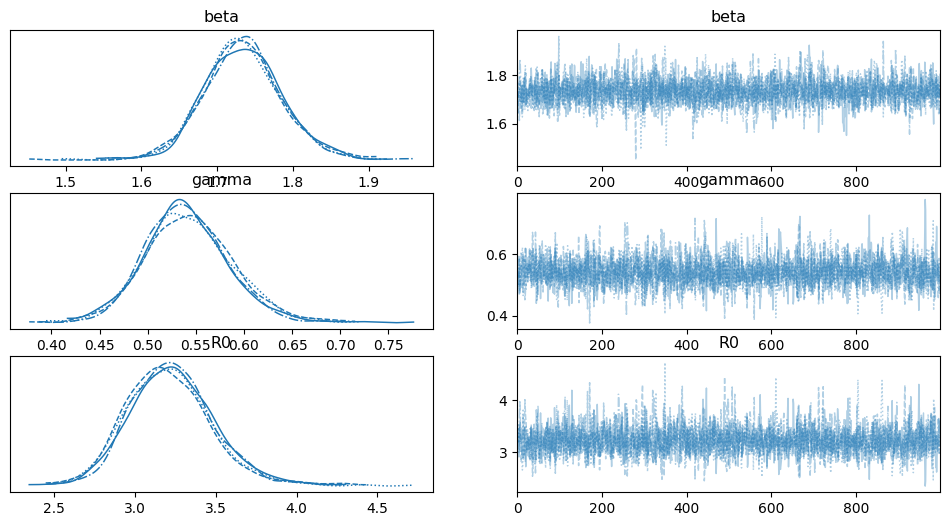

In [37]:
az.plot_trace(idata, var_names=["beta","gamma","R0"]); plt.show()

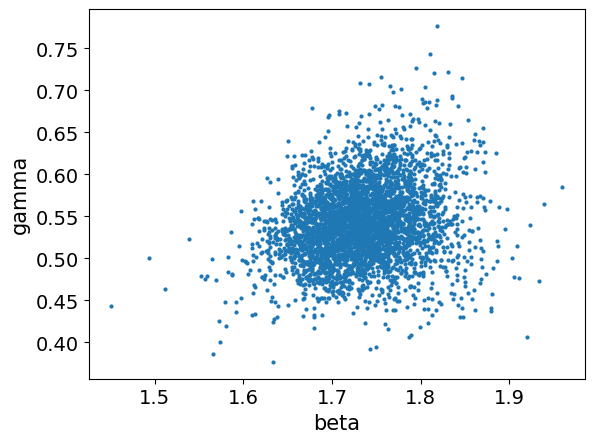

In [38]:
az.plot_pair(idata, var_names=["beta","gamma"], kind="scatter", divergences=True); plt.show()


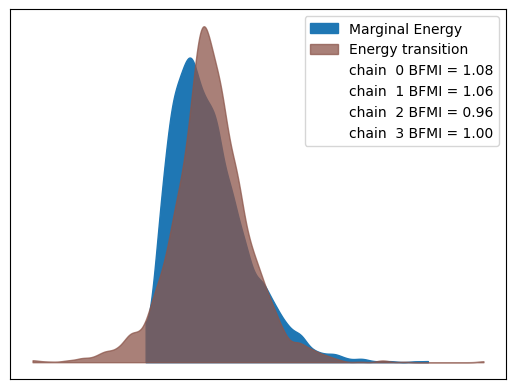

In [39]:
az.plot_energy(idata); plt.show()

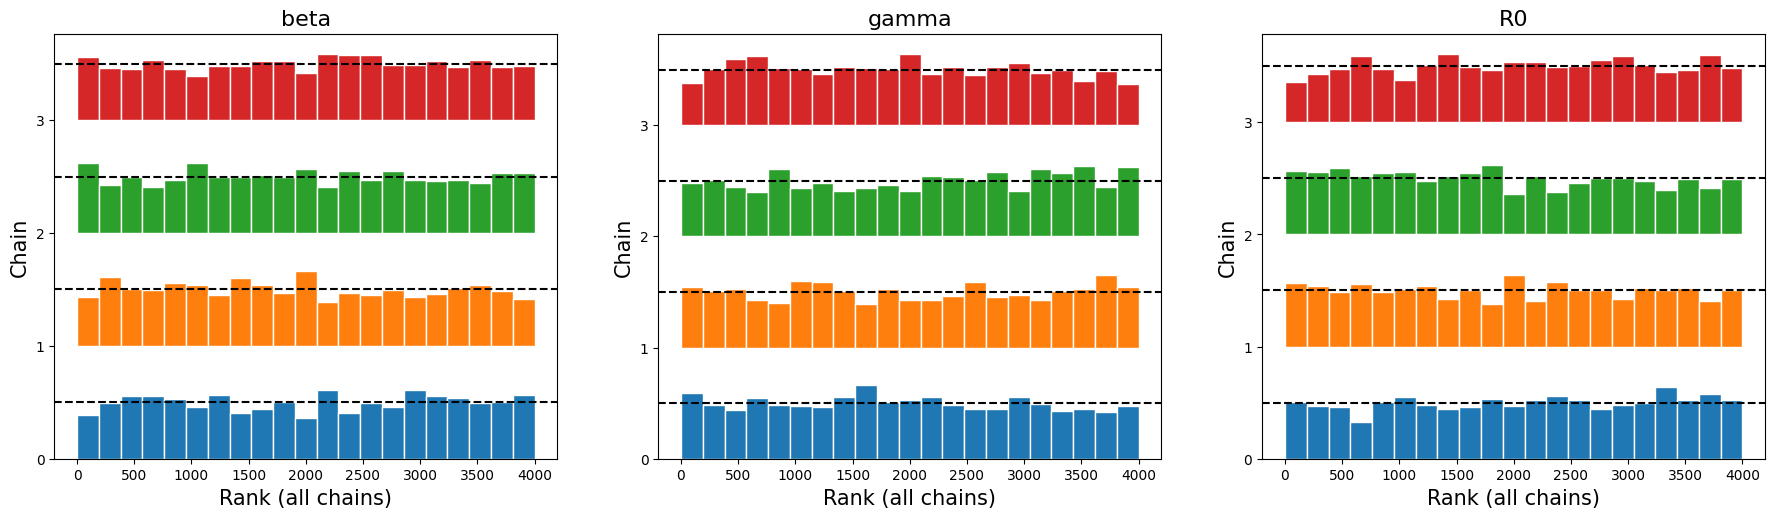

In [40]:
az.plot_rank(idata, var_names=["beta","gamma","R0"]); plt.show()

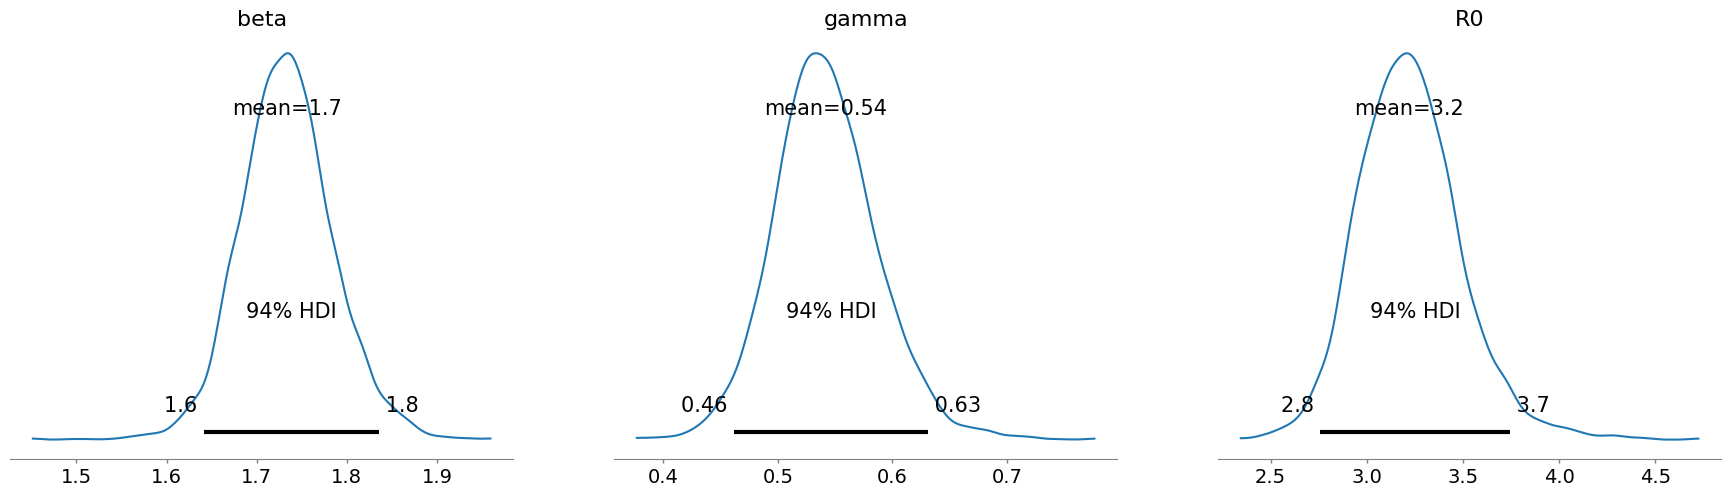

In [41]:
az.plot_posterior(idata, var_names=["beta","gamma","R0"]); plt.show()

In [43]:
print(fit2.diagnose())

Processing csv files: /tmp/tmpiv9oclkl/sir_negbin2_log2f_a0lmao/sir_negbin2_log2-20251111193857_1.csv, /tmp/tmpiv9oclkl/sir_negbin2_log2f_a0lmao/sir_negbin2_log2-20251111193857_2.csv, /tmp/tmpiv9oclkl/sir_negbin2_log2f_a0lmao/sir_negbin2_log2-20251111193857_3.csv, /tmp/tmpiv9oclkl/sir_negbin2_log2f_a0lmao/sir_negbin2_log2-20251111193857_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Effective sample size satisfactory.

Split R-hat values satisfactory all parameters.

Processing complete, no problems detected.



In [44]:
# Calculate WAIC
waic = az.waic(idata)
print("\nWAIC:")
print(waic)



WAIC:
Computed from 4000 posterior samples and 13 observations log-likelihood matrix.

          Estimate       SE
elpd_waic   -58.75     4.90
p_waic        1.49        -


In [34]:
# Calculate LOO
loo = az.loo(idata)
print("\nLOO:")
print(loo)


LOO:
Computed from 4000 posterior samples and 13 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -58.78     4.90
p_loo        1.53        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       13  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



In [45]:
df['in_bed']

,in_bed
0,3
1,8
2,26
3,76
4,225
5,298
6,258
7,233
8,189
9,128


In [46]:
idata

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats

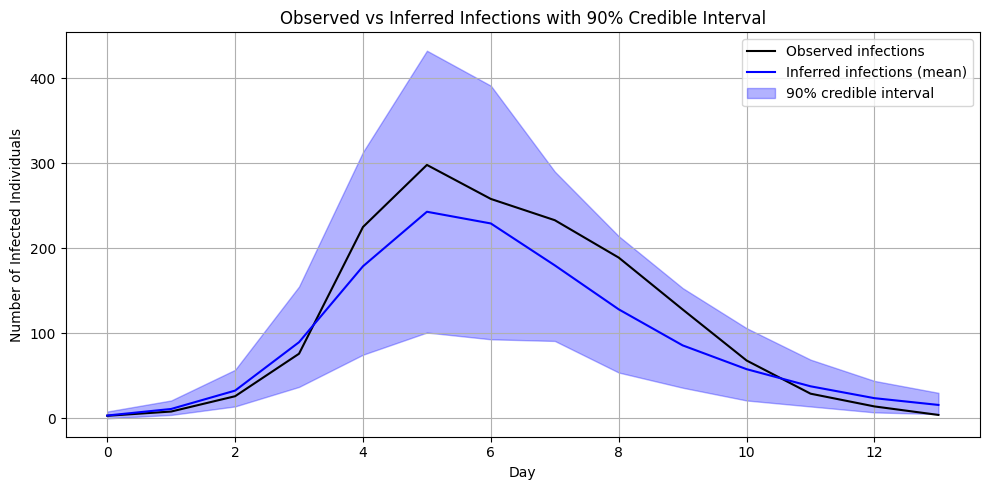

In [47]:
# ----------------------------------------
# 1. Extract posterior samples of I_t
# ----------------------------------------

# Thin to reduce memory load if needed
idata_thin = idata.sel(draw=slice(None, None, 10))  # Optional: use if large memory use

# Stack samples across chains and draws
I_t_samples = idata_thin.posterior["pred_cases"].stack(sample=("chain", "draw")).values  # shape: [time, samples]
#

# ----------------------------------------
# 2. Compute Posterior Mean and 90% HDI
# ----------------------------------------
I_t_mean = np.mean(I_t_samples, axis=1)
I_t_lower = np.percentile(I_t_samples, 5, axis=1)
I_t_upper = np.percentile(I_t_samples, 95, axis=1)

# ----------------------------------------
# 3. Plot Observed vs Inferred Infections
# ----------------------------------------

# If you have the original observed data in a variable like `infected`:
days = np.arange(len(I_t_mean))  # or use actual time values if available

plt.figure(figsize=(10, 5))
plt.plot(days, df["in_bed"], '-', label="Observed infections", color='black')
plt.plot(days, I_t_mean, label="Inferred infections (mean)", color='blue')
plt.fill_between(days, I_t_lower, I_t_upper, color='blue', alpha=0.3, label="90% credible interval")

plt.xlabel("Day")
plt.ylabel("Number of Infected Individuals")
plt.title("Observed vs Inferred Infections with 90% Credible Interval")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('school_out.png')
plt.savefig('school_out.pdf')
plt.show()


##IEMAG Irish Pandemic Data

In [48]:
print(os.getcwd())
print(os.listdir())

os.chdir("/content/")

# Verify
print(os.getcwd())
print(os.listdir())

/content
['.config', '.ipynb_checkpoints', 'cmdstan-2.23.0', 'school_out.pdf', 'school_out.png', 'WSL', 'colab-cmdstan-2.23.0.tar.gz', 'drive', 'data', 'school_summary.csv', 'stan', 'sample_data']
/content
['.config', '.ipynb_checkpoints', 'cmdstan-2.23.0', 'school_out.pdf', 'school_out.png', 'WSL', 'colab-cmdstan-2.23.0.tar.gz', 'drive', 'data', 'school_summary.csv', 'stan', 'sample_data']


In [53]:
# --- Paths ---
#os.chdir
csv_path = Path("data/case_data_IRL_20201111.csv")

In [54]:
# --- Load data ---
df = pd.read_csv(csv_path)

In [55]:
cases = df["daycount"].astype(int).to_numpy()
n_days = len(cases)

In [56]:
# --- Time axis used by Stan ODE block ---
t0 = 0.0
# Typical choice: one time unit per row. Stan expects strictly increasing ts:
ts = np.arange(1, n_days + 1, dtype=float)

In [57]:
# --- Population size (N)---
N = 4900000

In [58]:
# Initial conditions [S0, I0, R0]; common choice starts with 1 infected, 0 recovered.
y0 = np.array([N - 1, 1, 0], dtype=float)

In [59]:
# --- Build Stan data list (must match the Stan file's data block) ---
stan_data = {
    "n_days": int(n_days),
    "y0": y0.astype(float),
    "t0": float(t0),
    "ts": ts.astype(float),
    "N": int(N),
    "cases": cases.astype(int),
}

In [62]:
model4 = CmdStanModel(stan_file="stan/sir_incidence3.stan",
                     compile="stan --build=make TBB=true")
fit4 = model4.sample(data=stan_data, seed=123)

If you wish to force recompilation, use force_compile=True instead.


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

Exception: neg_binomial_2_lpmf: Location parameter[9] is -2.54251e-07, but must be positive finite! (in 'sir_incidence3.stan', line 60, column 2 to column 55)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence3.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence3.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence3.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence3.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence3.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence3.stan

	Chain 1 had 461 iterations at max treedepth (46.1%)
	Chain 2 had 473 iterations at max treedepth (47.3%)
	Chain 4 had 465 iterations at max treedepth (46.5%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [63]:
print(fit4.diagnose())

Processing csv files: /tmp/tmpiv9oclkl/sir_incidence3c2l69n_a/sir_incidence3-20251111194844_1.csv, /tmp/tmpiv9oclkl/sir_incidence3c2l69n_a/sir_incidence3-20251111194844_2.csv, /tmp/tmpiv9oclkl/sir_incidence3c2l69n_a/sir_incidence3-20251111194844_3.csv, /tmp/tmpiv9oclkl/sir_incidence3c2l69n_a/sir_incidence3-20251111194844_4.csv

Checking sampler transitions treedepth.
1399 of 4000 (34.98%) transitions hit the maximum treedepth limit of 10, or 2^10 leapfrog steps.
Trajectories that are prematurely terminated due to this limit will result in slow exploration.
For optimal performance, increase this limit.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
The E-BFMI, 0.00, is below the nominal threshold of 0.30 which suggests that HMC may have trouble exploring the target distribution.
If possible, try to reparameterize the model.

The following parameters had fewer than 0.001 effective draws per trans

In [64]:
fit4.summary()

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
lp__,-1.980860e+03,25.209800,35.722500,-2.043490e+03,-1.960490e+03,-1.958910e+03,2.00791,0.001590,30.92360
gamma,3.126050e+00,1.261700,1.802220,3.646400e-02,4.014200e+00,4.632880e+00,2.04035,0.001616,7.36380
beta,3.197950e+00,1.228810,1.755890,1.886260e-01,4.059820e+00,4.675000e+00,2.04187,0.001617,7.20926
phi_inv,5.762970e+00,0.699170,1.043010,4.680800e+00,5.328990e+00,7.796440e+00,2.22544,0.001762,3.03774
"y[1,1]",4.899994e+06,0.108410,4.848220,4.899990e+06,4.899990e+06,4.900000e+06,2000.00000,1.583790,1.55210
...,...,...,...,...,...,...,...,...,...
log_lik[249],-9.389410e+00,0.354219,0.528036,-1.041800e+01,-9.167980e+00,-8.859400e+00,2.22219,0.001760,3.03311
log_lik[250],-8.574960e+00,0.269869,0.397614,-9.345200e+00,-8.402240e+00,-8.193620e+00,2.17079,0.001719,3.42445
log_lik[251],-9.706190e+00,0.392611,0.591098,-1.085930e+01,-9.470550e+00,-9.090110e+00,2.26670,0.001795,2.79364
log_lik[252],-8.234480e+00,0.241301,0.354777,-8.918060e+00,-8.078550e+00,-7.895730e+00,2.16168,0.001712,3.51756


In [65]:
idata = az.from_cmdstanpy(posterior=fit4)

# Summary incl. mean, sd, mcse, r_hat, ess_bulk/tail
print(az.summary(idata, var_names=["beta","gamma","R0","phi_inv"], round_to=3))

          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta     3.198  1.756   0.183    4.648      0.866    0.489     7.234   
gamma    3.126  1.802   0.033    4.605      0.889    0.502     7.213   
R0       2.012  1.738   1.008    5.170      0.864    0.501     7.213   
phi_inv  5.763  1.043   4.527    7.799      0.489    0.272     7.249   

         ess_tail  r_hat  
beta       32.220  1.533  
gamma      32.073  1.533  
R0         30.238  1.533  
phi_inv    32.795  1.535  


In [66]:
# Convert your CmdStanPy fit to InferenceData
idata = az.from_cmdstanpy(posterior=fit4)

# See what sampler stats are present
print("sample_stats vars:", list(idata.sample_stats.data_vars))

# Divergences
div = idata.sample_stats["diverging"]
n_div = int(div.sum())
print("Divergences:", n_div)

# Tree depth (ArviZ name is 'tree_depth')
if "tree_depth" in idata.sample_stats:
    td = idata.sample_stats["tree_depth"]
    max_td = int(td.max())
    n_max_td = int((td == max_td).sum())
    print(f"Hits at max tree depth ({max_td}):", n_max_td)
else:
    print("No 'tree_depth' in sample_stats (backend/version mismatch?).")

# BFMI (energy diagnostic; <~0.3 can be concerning)
bfmi_values = az.bfmi(idata)
if np.isscalar(bfmi_values):
    print("BFMI:", float(bfmi_values))
else:
    print("Mean BFMI:", float(np.mean(bfmi_values)))

# Step size & acceptance rate
if "step_size" in idata.sample_stats:
    print("Mean step_size:", float(idata.sample_stats["step_size"].mean()))
else:
    print("No 'step_size' in sample_stats.")

# ArviZ uses 'acceptance_rate' for Stan backends
if "acceptance_rate" in idata.sample_stats:
    print("Mean acceptance_rate:", float(idata.sample_stats["acceptance_rate"].mean()))
else:
    print("No 'acceptance_rate' in sample_stats.")

sample_stats vars: ['acceptance_rate', 'diverging', 'energy', 'lp', 'n_steps', 'step_size', 'tree_depth']
Divergences: 0
Hits at max tree depth (10): 1399
Mean BFMI: 1.039863715430648
Mean step_size: 0.13701104999998281
Mean acceptance_rate: 0.9248985622500021


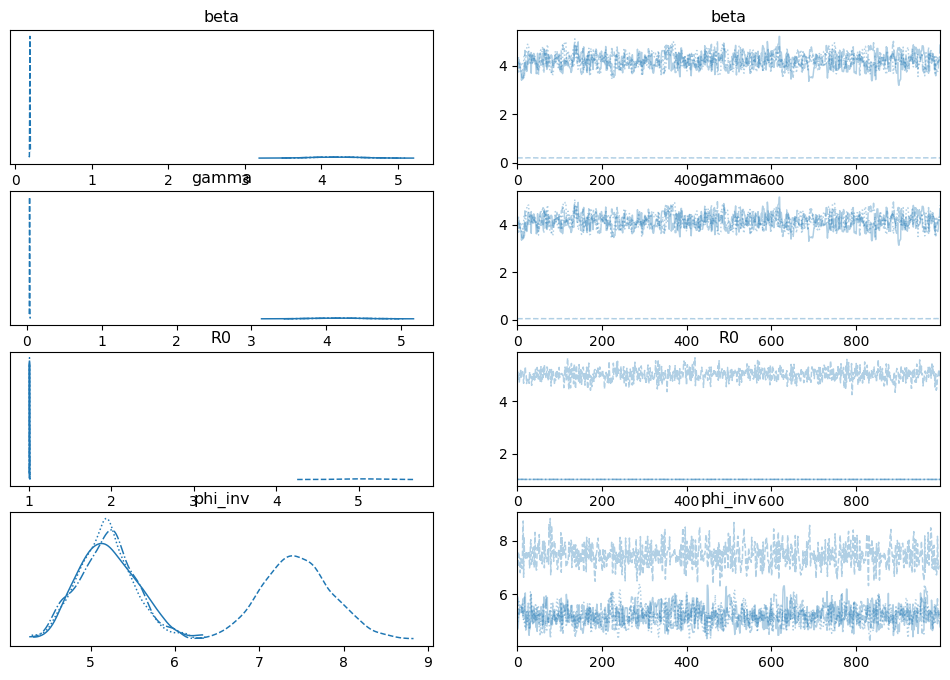

In [67]:
az.plot_trace(idata, var_names=["beta","gamma","R0","phi_inv"]); plt.show()

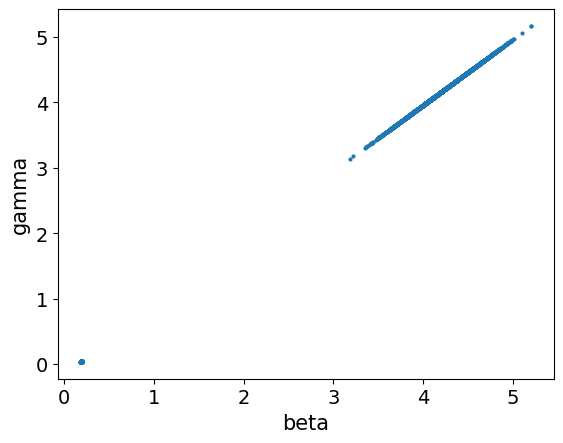

In [68]:
az.plot_pair(idata, var_names=["beta","gamma"], kind="scatter", divergences=True); plt.show()

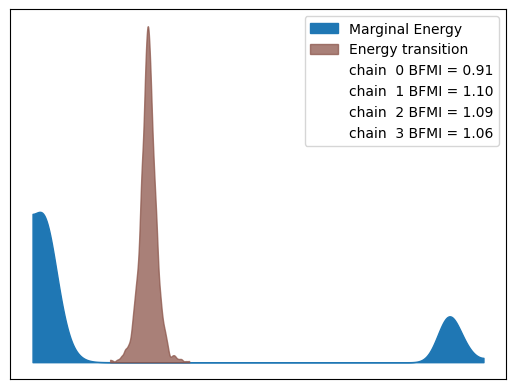

In [69]:
az.plot_energy(idata); plt.show()

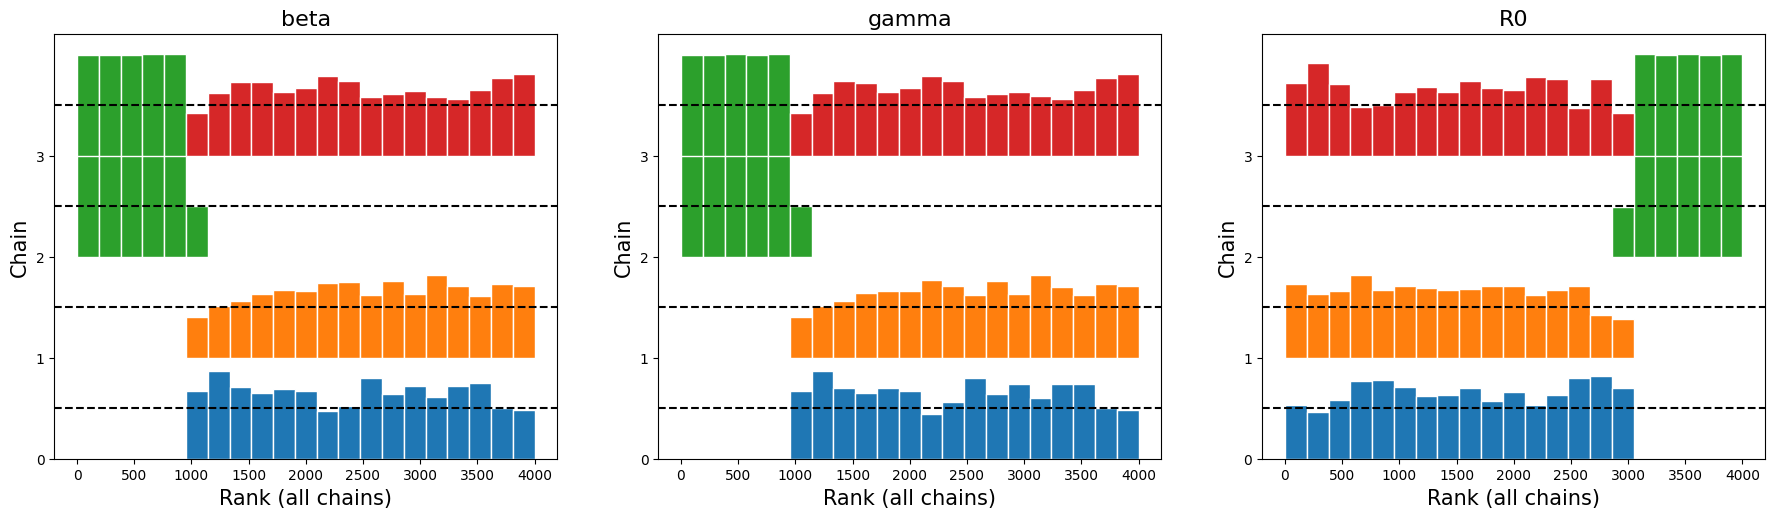

In [70]:
az.plot_rank(idata, var_names=["beta","gamma","R0"]); plt.show()

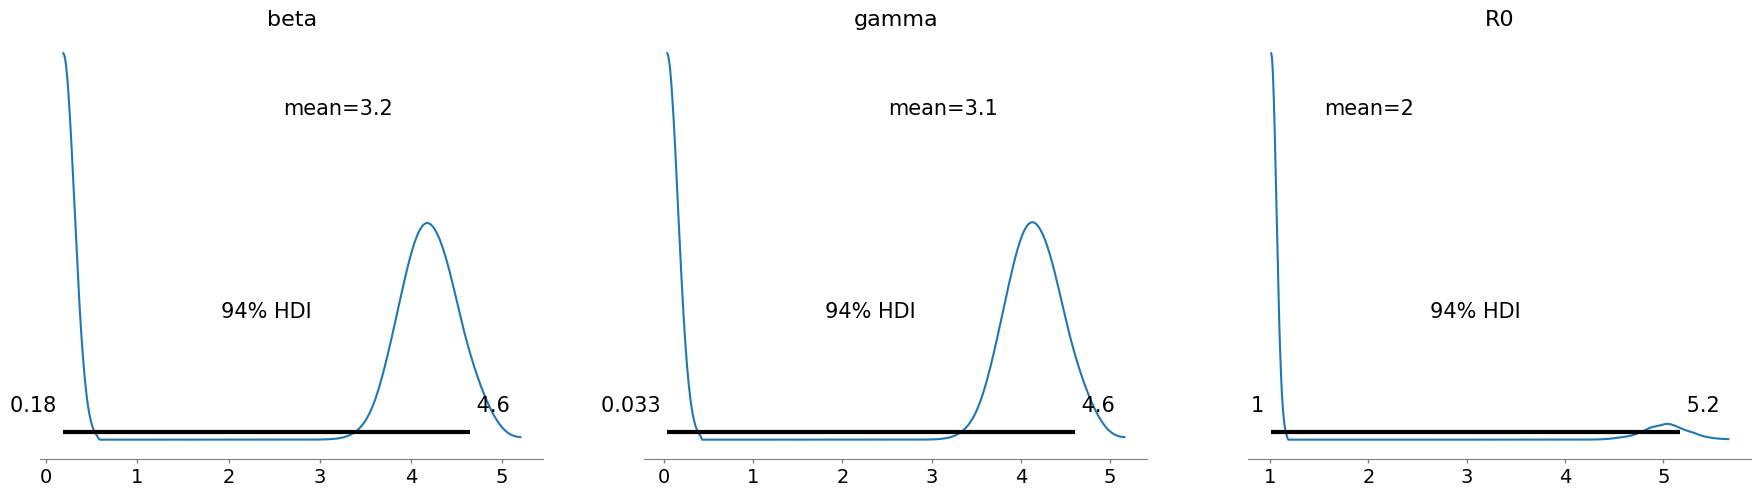

In [71]:
az.plot_posterior(idata, var_names=["beta","gamma","R0"]); plt.show()

In [72]:
# Calculate WAIC
waic = az.waic(idata)
print("\nWAIC:")
print(waic)



WAIC:
Computed from 4000 posterior samples and 253 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -1967.17    38.43
p_waic       66.52        -

There has been a warning during the calculation. Please check the results.


/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


In [73]:
# Calculate LOO
loo = az.loo(idata)
print("\nLOO:")
print(loo)


LOO:
Computed from 4000 posterior samples and 253 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1962.64    38.00
p_loo       61.99        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      253  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



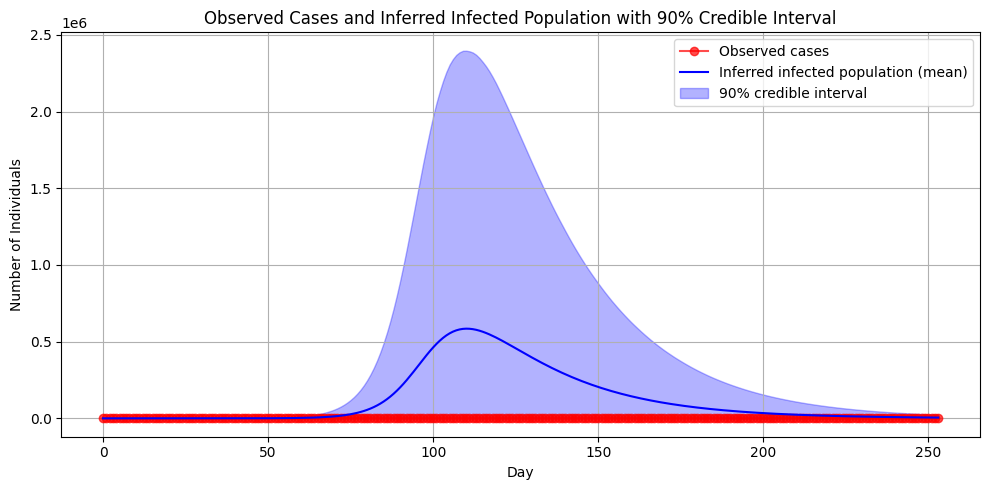

In [74]:
# ----------------------------------------
# 1. Extract posterior samples of I_t (Infected Population)
# ----------------------------------------

# Thin to reduce memory load if needed (optional)
# idata_thin = idata.sel(draw=slice(None, None, 10))

# Stack samples across chains and draws for the Infected compartment (second column of y)
# The shape of y in Stan is (n_days, 3) for (S, I, R)
# In ArviZ idata, y will typically have dimensions (chain, draw, y_dim_0, y_dim_1)
# where y_dim_0 corresponds to n_days and y_dim_1 corresponds to the compartments (S, I, R)
# We want the Infected compartment, which is y_dim_1 index 1.
# We then stack chain and draw dimensions to get (sample, n_days) or (n_days, sample) depending on stacking order
# Let's stack to get (n_days, sample) for easier calculation along axis=1
I_t_samples = idata.posterior["y"].sel(y_dim_1=1).stack(sample=("chain", "draw")).values # shape: [n_days, samples]


# ----------------------------------------
# 2. Compute Posterior Mean and 90% HDI
# ----------------------------------------
# Now I_t_samples is a 2D numpy array (n_days, samples)
I_t_mean = np.mean(I_t_samples, axis=1)
I_t_lower = np.percentile(I_t_samples, 5, axis=1)
I_t_upper = np.percentile(I_t_samples, 95, axis=1)

# ----------------------------------------
# 3. Plot Observed vs Inferred Infections
# ----------------------------------------

# Create a time axis with length n_days
days = np.arange(len(I_t_mean)) # This will now be of length n_days

plt.figure(figsize=(10, 5))
# Plot observed cases
plt.plot(days, df["daycount"], 'o-', label="Observed cases", color='red', alpha=0.7) # Use df["daycount"] which has length n_days

# Plot inferred infections (mean and credible interval)
plt.plot(days, I_t_mean, label="Inferred infected population (mean)", color='blue')
plt.fill_between(days, I_t_lower, I_t_upper, color='blue', alpha=0.3, label="90% credible interval")

plt.xlabel("Day")
plt.ylabel("Number of Individuals")
plt.title("Observed Cases and Inferred Infected Population with 90% Credible Interval")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('iemag4.png')
plt.savefig('iemag4.pdf')
plt.show()

In [111]:
# as below, with tree depth increased to 20
# very high rhat don't look good
	Mean	MCSE	StdDev	5%	50%	95%	N_Eff	N_Eff/s	R_hat
lp__	-1.990300e+03	28.118600	39.84050	-2.031720e+03	-1.958860e+03	-1.949260e+03	2.00752	0.001756	34.48230
gamma	2.139090e+00	1.484880	2.11170	3.564630e-02	3.373980e+00	4.611210e+00	2.02247	0.001769	10.69290
beta	2.240260e+00	1.446250	2.05713	1.908440e-01	3.426350e+00	4.654580e+00	2.02320	0.001769	10.46710
phi_inv	6.077930e+00	0.773399	1.14757	4.563950e+00	6.020890e+00	7.694200e+00	2.20166	0.001925	3.20287
y[1,1]

IndentationError: unexpected indent (ipython-input-2818832432.py, line 3)

In [ ]:
# with lower nonzero bound on phi inv and uniform distributi

In [72]:
index	Mean	MCSE	StdDev	5%	50%	95%	N_Eff	N_Eff/s	R_hat
lp__	-1950.49	0.0405791	1.2223	-1952.95	-1950.18	-1949.12	907.3	0.423439	1.00404
gamma	4.24313	0.0145886	0.30902	3.75723	4.22564	4.77674	448.691	0.209405	1.01903
beta	4.28953	0.0145114	0.307548	3.80667	4.2719	4.8206	449.167	0.209627	1.01902
phi_inv	4.97812	0.0116236	0.326373	4.43764	4.97099	5.51717	788.403	0.367949	1.01259
y[1,1]	5899991.0	0.105436	2.88355	5899990.0	5899990.0	5900000.0	747.96	0.349074	1.0064

SyntaxError: invalid syntax (ipython-input-4294671269.py, line 1)

In [ ]:
#

## Irish data with tighter priors

In [75]:

# Replace the prior lines with tighter priors
#stan_code = stan_code.replace("beta ~ normal(2, 1);", "beta ~ normal(2, 0.5);")
#stan_code = stan_code.replace("gamma ~ normal(0.4, 0.5);", "gamma ~ normal(0.4, 0.2);")
#stan_code = stan_code.replace("phi_inv ~ exponential(5);", "phi_inv ~ exponential(10);")



In [88]:
# --- Paths ---
#os.chdir
csv_path = Path("data/case_data_IRL_20201111.csv")
#csv_path = Path("case_data_IRL_shorter.csv")

In [89]:
# --- Load data ---
df = pd.read_csv(csv_path)

In [90]:
cases = df["daycount"].astype(int).to_numpy()
n_days = len(cases)

In [91]:
# --- Time axis used by Stan ODE block ---
t0 = 0.0
# Typical choice: one time unit per row. Stan expects strictly increasing ts:
ts = np.arange(1, n_days + 1, dtype=float)

In [92]:
# --- Population size (N)---
N = 4900000

In [93]:
# Initial conditions [S0, I0, R0]; common choice starts with 1 infected, 0 recovered.
y0 = np.array([N - 1, 1, 0], dtype=float)

In [94]:
# --- Build Stan data list (must match the Stan file's data block) ---
stan_data = {
    "n_days": int(n_days),
    "y0": y0.astype(float),
    "t0": float(t0),
    "ts": ts.astype(float),
    "N": int(N),
    "cases": cases.astype(int),
}

In [95]:
model5 = CmdStanModel(stan_file="stan/sir_incidence4.stan",
                     compile="stan --build=make TBB=true")
fit5 = model5.sample(data=stan_data, seed=123,adapt_delta=0.95, max_treedepth=12, iter_warmup=1500)

If you wish to force recompilation, use force_compile=True instead.


chain 1:   0%|          | 0/2500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2500 [00:00<?, ?it/s, (Warmup)]

Exception: neg_binomial_2_lpmf: Location parameter[9] is -2.54251e-07, but must be positive finite! (in 'sir_incidence4.stan', line 60, column 2 to column 55)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence4.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence4.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence4.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence4.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence4.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence4.stan

In [96]:
print(fit5.diagnose())

Processing csv files: /tmp/tmpiv9oclkl/sir_incidence42245e5is/sir_incidence4-20251111210651_1.csv, /tmp/tmpiv9oclkl/sir_incidence42245e5is/sir_incidence4-20251111210651_2.csv, /tmp/tmpiv9oclkl/sir_incidence42245e5is/sir_incidence4-20251111210651_3.csv, /tmp/tmpiv9oclkl/sir_incidence42245e5is/sir_incidence4-20251111210651_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
The E-BFMI, 0.02, is below the nominal threshold of 0.30 which suggests that HMC may have trouble exploring the target distribution.
If possible, try to reparameterize the model.

The following parameters had fewer than 0.001 effective draws per transition:
  gamma, beta, phi_inv, y[16,1], y[19,1], y[20,1], y[22,1], y[23,1], y[24,1], y[25,1], y[26,1], y[27,1], y[28,1], y[29,1], y[30,1], y[31,1], y[32,1], y[33,1], y[36,1], y[37,1], y[38,1], y[

In [97]:
print(fit5.summary())
fit5.summary().to_csv("fit5_summary.csv", index=True)

                      Mean       MCSE     StdDev            5%           50%  \
lp__         -2.059520e+03  10.001800  14.208800 -2.084840e+03 -2.051550e+03   
gamma         1.608150e+00   0.641072   0.913977  3.670950e-02  2.071080e+00   
beta          1.689920e+00   0.612127   0.873153  1.891770e-01  2.129230e+00   
phi_inv       5.936120e+00   0.310434   0.545457  5.199480e+00  5.834250e+00   
y[1,1]        4.900000e+06        NaN   0.000000  4.900000e+06  4.900000e+06   
...                    ...        ...        ...           ...           ...   
log_lik[249] -9.616300e+00   0.317632   0.490609 -1.056390e+01 -9.438710e+00   
log_lik[250] -8.747090e+00   0.223026   0.342490 -9.405150e+00 -8.621940e+00   
log_lik[251] -1.000270e+01   0.346031   0.547155 -1.105250e+01 -9.824080e+00   
log_lik[252] -8.401920e+00   0.186706   0.289392 -8.954140e+00 -8.301690e+00   
log_lik[253] -8.473940e+00   0.189883   0.297651 -9.037020e+00 -8.374600e+00   

                       95%    N_Eff   N

In [98]:
idata = az.from_cmdstanpy(posterior=fit5)

# Summary incl. mean, sd, mcse, r_hat, ess_bulk/tail
print(az.summary(idata, var_names=["beta","gamma","R0","phi_inv"], round_to=3))

          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta     1.690  0.873   0.184    2.386      0.431    0.245     7.350   
gamma    1.608  0.914   0.034    2.330      0.452    0.256     7.329   
R0       2.021  1.725   1.021    5.155      0.857    0.497     7.282   
phi_inv  5.936  0.545   5.131    7.072      0.213    0.093     7.924   

         ess_tail  r_hat  
beta       33.162  1.537  
gamma      29.675  1.537  
R0         29.107  1.537  
phi_inv    28.394  1.453  


In [99]:
# Convert your CmdStanPy fit to InferenceData
idata = az.from_cmdstanpy(posterior=fit5)

# See what sampler stats are present
print("sample_stats vars:", list(idata.sample_stats.data_vars))

# Divergences
div = idata.sample_stats["diverging"]
n_div = int(div.sum())
print("Divergences:", n_div)

# Tree depth (ArviZ name is 'tree_depth')
if "tree_depth" in idata.sample_stats:
    td = idata.sample_stats["tree_depth"]
    max_td = int(td.max())
    n_max_td = int((td == max_td).sum())
    print(f"Hits at max tree depth ({max_td}):", n_max_td)
else:
    print("No 'tree_depth' in sample_stats (backend/version mismatch?).")

# BFMI (energy diagnostic; <~0.3 can be concerning)
bfmi_values = az.bfmi(idata)
if np.isscalar(bfmi_values):
    print("BFMI:", float(bfmi_values))
else:
    print("Mean BFMI:", float(np.mean(bfmi_values)))

# Step size & acceptance rate
if "step_size" in idata.sample_stats:
    print("Mean step_size:", float(idata.sample_stats["step_size"].mean()))
else:
    print("No 'step_size' in sample_stats.")

# ArviZ uses 'acceptance_rate' for Stan backends
if "acceptance_rate" in idata.sample_stats:
    print("Mean acceptance_rate:", float(idata.sample_stats["acceptance_rate"].mean()))
else:
    print("No 'acceptance_rate' in sample_stats.")

sample_stats vars: ['acceptance_rate', 'diverging', 'energy', 'lp', 'n_steps', 'step_size', 'tree_depth']
Divergences: 0
Hits at max tree depth (10): 714
Mean BFMI: 1.0426875495045518
Mean step_size: 0.1116899275000054
Mean acceptance_rate: 0.9573238799999995


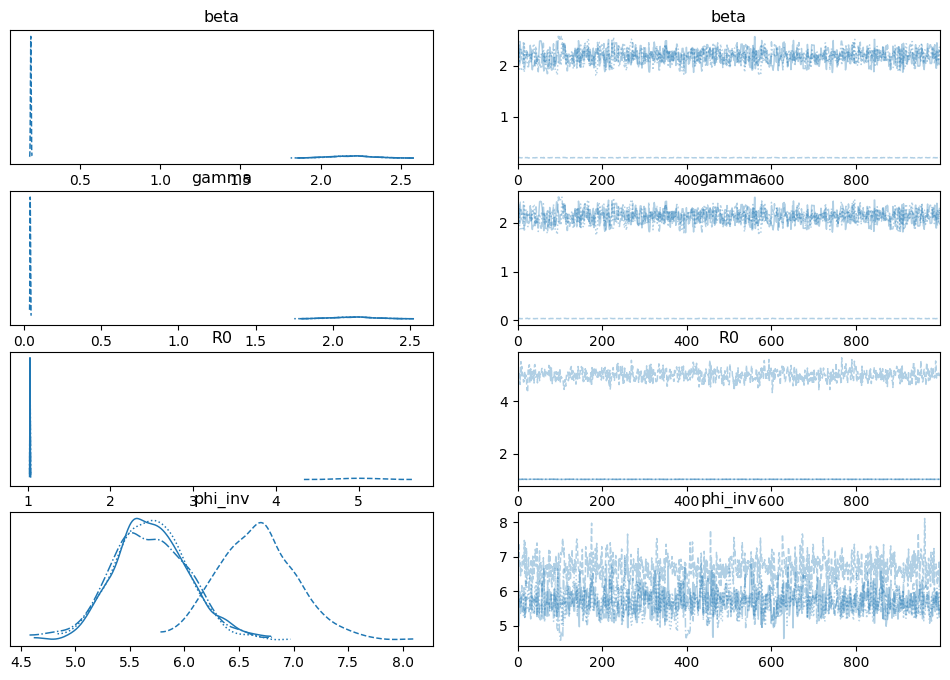

In [100]:
az.plot_trace(idata, var_names=["beta","gamma","R0","phi_inv"]); plt.show()

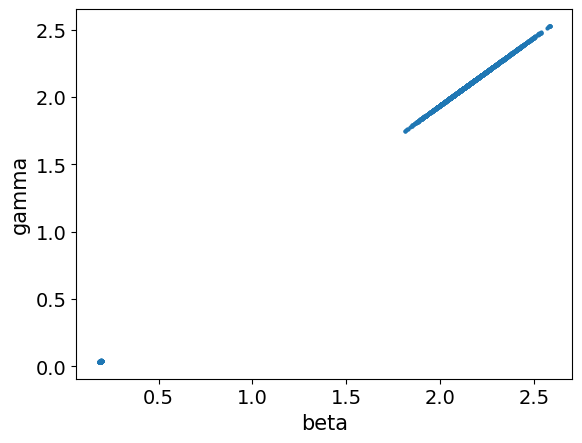

In [101]:
az.plot_pair(idata, var_names=["beta","gamma"], kind="scatter", divergences=True); plt.show()

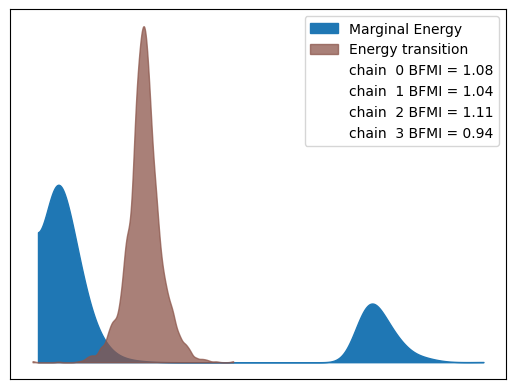

In [102]:
az.plot_energy(idata); plt.show()

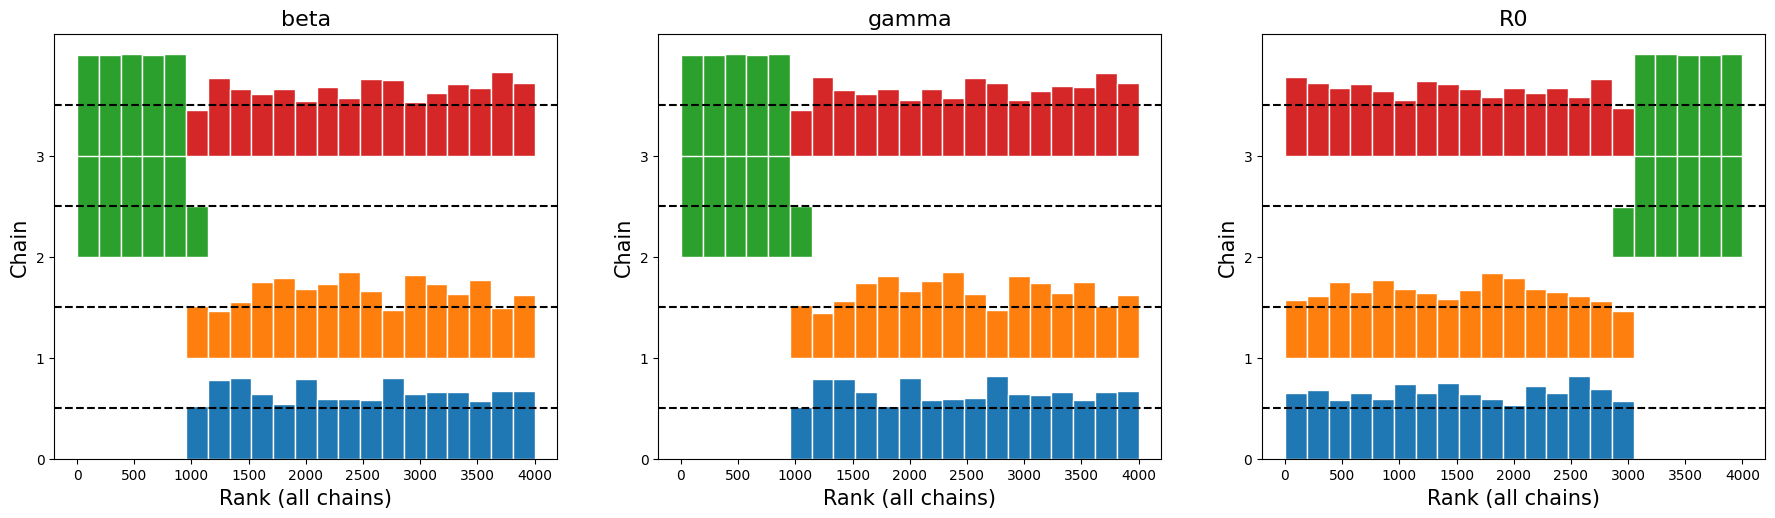

In [103]:
az.plot_rank(idata, var_names=["beta","gamma","R0"]); plt.show()

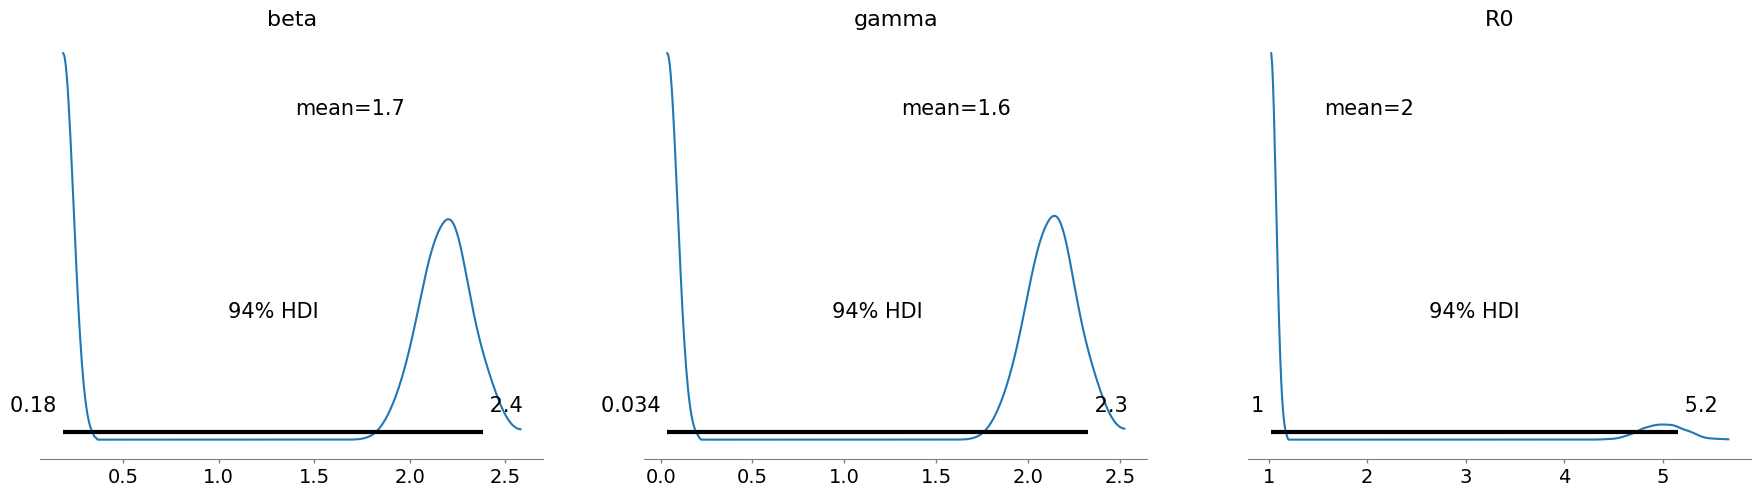

In [104]:
az.plot_posterior(idata, var_names=["beta","gamma","R0"]); plt.show()

In [105]:
# Calculate WAIC
waic = az.waic(idata)
print("\nWAIC:")
print(waic)



WAIC:
Computed from 4000 posterior samples and 253 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -2007.16    41.23
p_waic       69.45        -

There has been a warning during the calculation. Please check the results.


/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


In [106]:
# Calculate LOO
loo = az.loo(idata)
print("\nLOO:")
print(loo)


LOO:
Computed from 4000 posterior samples and 253 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2001.36    40.51
p_loo       63.65        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      253  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



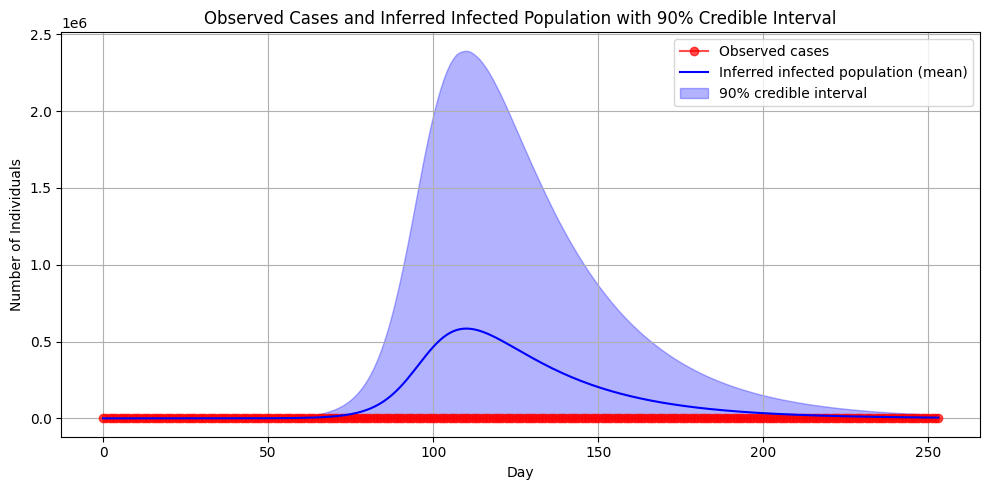

In [107]:
# ----------------------------------------
# 1. Extract posterior samples of I_t (Infected Population)
# ----------------------------------------

# Thin to reduce memory load if needed (optional)
# idata_thin = idata.sel(draw=slice(None, None, 10))

I_t_samples = idata.posterior["y"].sel(y_dim_1=1).stack(sample=("chain", "draw")).values # shape: [n_days, samples]

# ----------------------------------------
# 2. Compute Posterior Mean and 90% HDI
# ----------------------------------------
# Now I_t_samples is a 2D numpy array (n_days, samples)
I_t_mean = np.mean(I_t_samples, axis=1)
I_t_lower = np.percentile(I_t_samples, 5, axis=1)
I_t_upper = np.percentile(I_t_samples, 95, axis=1)

# ----------------------------------------
# 3. Plot Observed vs Inferred Infections
# ----------------------------------------

# Create a time axis with length n_days
days = np.arange(len(I_t_mean)) # This will now be of length n_days

plt.figure(figsize=(10, 5))
# Plot observed cases
plt.plot(days, df["daycount"], 'o-', label="Observed cases", color='red', alpha=0.7) # Use df["daycount"] which has length n_days

# Plot inferred infections (mean and credible interval)
plt.plot(days, I_t_mean, label="Inferred infected population (mean)", color='blue')
plt.fill_between(days, I_t_lower, I_t_upper, color='blue', alpha=0.3, label="90% credible interval")

plt.xlabel("Day")
plt.ylabel("Number of Individuals")
plt.title("Observed Cases and Inferred Infected Population with 90% Credible Interval")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('iemag5.png')
plt.savefig('iemag5.pdf')
plt.show()

## Add underreporting to the model

In [79]:
# --- Paths ---
#os.chdir
csv_path = Path("case_data_IRL_20201111.csv")

In [80]:
# --- Load data ---
df = pd.read_csv(csv_path)

In [81]:
cases = df["daycount"].astype(int).to_numpy()
n_days = len(cases)

In [82]:
# --- Time axis used by Stan ODE block ---
t0 = 0.0
# Typical choice: one time unit per row. Stan expects strictly increasing ts:
ts = np.arange(1, n_days + 1, dtype=float)

In [83]:
# --- Population size (N)---
N = 4900000

In [84]:
# Initial conditions [S0, I0, R0]; common choice starts with 1 infected, 0 recovered.
y0 = np.array([N - 1, 1, 0], dtype=float)

In [86]:
# --- Build Stan data list (must match the Stan file's data block) ---
stan_data = {
    "n_days": int(n_days),
    "y0": y0.astype(float),
    "t0": float(t0),
    "ts": ts.astype(float),
    "N": int(N),
    "cases": cases.astype(int),
}

In [102]:
model = CmdStanModel(stan_file="sir_underreporting.stan",
                     compile="stan --build=make TBB=true")
fit6 = model.sample(data=stan_data, seed=123)

If you wish to force recompilation, use force_compile=True instead.
--- Translating Stan model to C++ code ---
bin/stanc --filename-in-msg=sir_underreporting.stan --o=/content/WSL/sir_underreporting.hpp /content/WSL/sir_underreporting.stan
Warning in 'sir_underreporting.stan', line 44, column 6: integrate_ode_rk45
    is deprecated and will be removed in Stan 3.0. Use ode_rk45 instead. 
    The new interface is slightly different, see:
    https://mc-stan.org/users/documentation/case-studies/convert_odes.html

--- Compiling C++ code ---
g++ -std=c++17 -pthread -D_REENTRANT -Wno-sign-compare -Wno-ignored-attributes -Wno-class-memaccess      -I stan/lib/stan_math/lib/tbb_2020.3/include    -O3 -I src -I stan/src -I stan/lib/rapidjson_1.1.0/ -I lib/CLI11-1.9.1/ -I stan/lib/stan_math/ -I stan/lib/stan_math/lib/eigen_3.4.0 -I stan/lib/stan_math/lib/boost_1.84.0 -I stan/lib/stan_math/lib/sundials_6.1.1/include -I stan/lib/stan_math/lib/sundials_6.1.1/src/sundials    -DBOOST_DISABLE_ASSERTS   

chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

Exception: neg_binomial_2_lpmf: Location parameter[9] is -9.97934e-08, but must be positive finite! (in 'sir_underreporting.stan', line 58, column 2 to column 55)
	Exception: neg_binomial_2_lpmf: Location parameter[55] is -1.02489e-09, but must be positive finite! (in 'sir_underreporting.stan', line 58, column 2 to column 55)
	Exception: neg_binomial_2_lpmf: Location parameter[12] is -3.15851e-08, but must be positive finite! (in 'sir_underreporting.stan', line 58, column 2 to column 55)
	Exception: neg_binomial_2_lpmf: Location parameter[4] is -6.1061e-08, but must be positive finite! (in 'sir_underreporting.stan', line 58, column 2 to column 55)
	Exception: neg_binomial_2_lpmf: Location parameter[56] is -1.25558e-08, but must be positive finite! (in 'sir_underreporting.stan', line 58, column 2 to column 55)
	Exception: neg_binomial_2_lpmf: Location parameter[131] is -1.07283e-09, but must be positive finite! (in 'sir_underreporting.stan', line 58, column 2 to column 55)
	Exception: n

	Chain 4 had 732 iterations at max treedepth (73.2%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [103]:
print(fit6.diagnose())

Processing csv files: /tmp/tmp3oginmh4/sir_underreporting48e457fh/sir_underreporting-20251110232722_1.csv, /tmp/tmp3oginmh4/sir_underreporting48e457fh/sir_underreporting-20251110232722_2.csv, /tmp/tmp3oginmh4/sir_underreporting48e457fh/sir_underreporting-20251110232722_3.csv, /tmp/tmp3oginmh4/sir_underreporting48e457fh/sir_underreporting-20251110232722_4.csv

Checking sampler transitions treedepth.
733 of 4000 (18.32%) transitions hit the maximum treedepth limit of 10, or 2^10 leapfrog steps.
Trajectories that are prematurely terminated due to this limit will result in slow exploration.
For optimal performance, increase this limit.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
The E-BFMI, 0.00, is below the nominal threshold of 0.30 which suggests that HMC may have trouble exploring the target distribution.
If possible, try to reparameterize the model.

The following parameters had fewer than 

In [104]:
fit6.summary()

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
lp__,-2033.510000,25.177200,35.680200,-2056.420000,-2053.300000,-1970.610000,2.00835,0.006552,27.62190
gamma,1.060330,1.250830,1.776310,0.035302,0.039014,4.355340,2.01670,0.006579,13.31420
beta,1.186130,1.217940,1.729810,0.187197,0.191959,4.399030,2.01718,0.006581,13.02920
phi_inv,6.957090,0.704570,1.063710,4.980810,7.330750,8.190270,2.27929,0.007436,2.73520
p_reported,0.988492,0.000154,0.007993,0.973119,0.990358,0.998019,2699.87000,8.808060,1.00137
...,...,...,...,...,...,...,...,...,...
log_lik[249],-9.975960,0.357315,0.535008,-10.572800,-10.165200,-8.964900,2.24191,0.007314,2.91593
log_lik[250],-9.024890,0.271721,0.401757,-9.447570,-9.179250,-8.270750,2.18616,0.007132,3.29225
log_lik[251],-10.354400,0.396212,0.598483,-11.044200,-10.553800,-9.220270,2.28164,0.007444,2.72432
log_lik[252],-8.637930,0.242764,0.357773,-9.006160,-8.780970,-7.965310,2.17194,0.007086,3.41879


In [106]:
idata = az.from_cmdstanpy(posterior=fit6)

# Summary incl. mean, sd, mcse, r_hat, ess_bulk/tail
print(az.summary(idata, var_names=["beta","gamma","R0","phi_inv"], round_to=3))

          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta     1.186  1.730   0.183    4.367      0.859    0.499     7.228   
gamma    1.060  1.776   0.033    4.323      0.882    0.513     7.221   
R0       4.008  1.741   1.008    5.320      0.862    0.492     7.203   
phi_inv  6.957  1.064   4.836    8.259      0.492    0.256     7.147   

         ess_tail  r_hat  
beta       42.373  1.528  
gamma      42.373  1.528  
R0         35.044  1.528  
phi_inv    31.106  1.531  


In [107]:
# Convert your CmdStanPy fit to InferenceData
idata = az.from_cmdstanpy(posterior=fit6)

# See what sampler stats are present
print("sample_stats vars:", list(idata.sample_stats.data_vars))

# Divergences
div = idata.sample_stats["diverging"]
n_div = int(div.sum())
print("Divergences:", n_div)

# Tree depth (ArviZ name is 'tree_depth')
if "tree_depth" in idata.sample_stats:
    td = idata.sample_stats["tree_depth"]
    max_td = int(td.max())
    n_max_td = int((td == max_td).sum())
    print(f"Hits at max tree depth ({max_td}):", n_max_td)
else:
    print("No 'tree_depth' in sample_stats (backend/version mismatch?).")

# BFMI (energy diagnostic; <~0.3 can be concerning)
bfmi_values = az.bfmi(idata)
if np.isscalar(bfmi_values):
    print("BFMI:", float(bfmi_values))
else:
    print("Mean BFMI:", float(np.mean(bfmi_values)))

# Step size & acceptance rate
if "step_size" in idata.sample_stats:
    print("Mean step_size:", float(idata.sample_stats["step_size"].mean()))
else:
    print("No 'step_size' in sample_stats.")

# ArviZ uses 'acceptance_rate' for Stan backends
if "acceptance_rate" in idata.sample_stats:
    print("Mean acceptance_rate:", float(idata.sample_stats["acceptance_rate"].mean()))
else:
    print("No 'acceptance_rate' in sample_stats.")

sample_stats vars: ['acceptance_rate', 'diverging', 'energy', 'lp', 'n_steps', 'step_size', 'tree_depth']
Divergences: 0
Hits at max tree depth (10): 733
Mean BFMI: 1.120908798164761
Mean step_size: 0.41869049250001683
Mean acceptance_rate: 0.9167764968999979


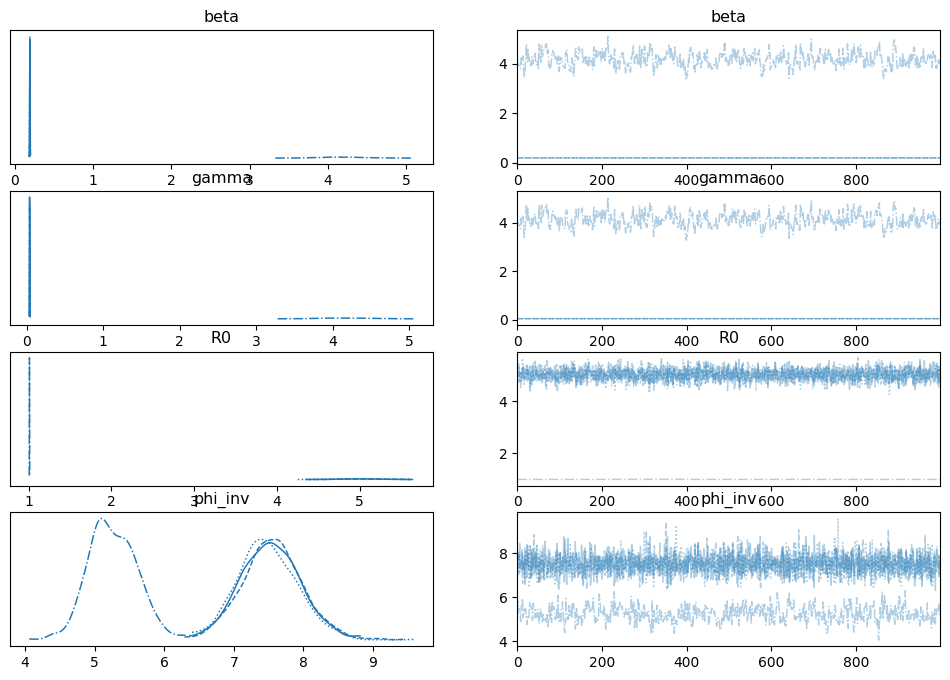

In [108]:
az.plot_trace(idata, var_names=["beta","gamma","R0","phi_inv"]); plt.show()

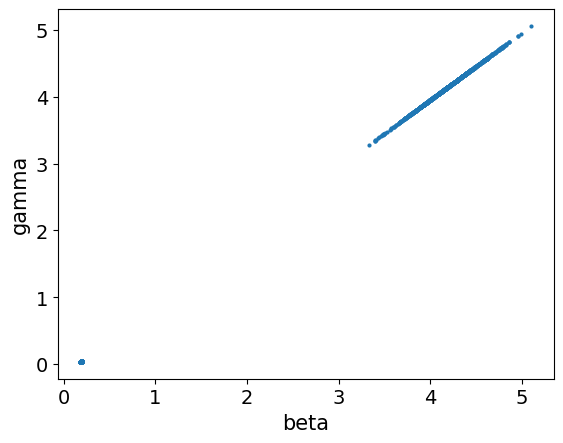

In [109]:
az.plot_pair(idata, var_names=["beta","gamma"], kind="scatter", divergences=True); plt.show()

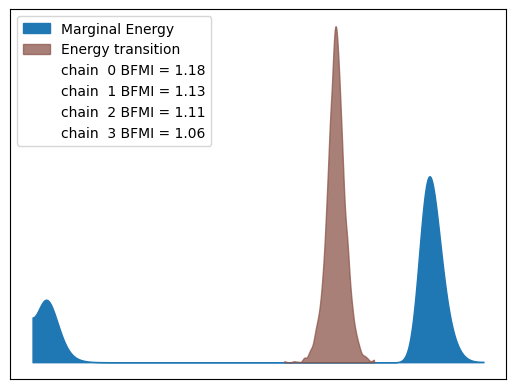

In [111]:
az.plot_energy(idata); plt.show()

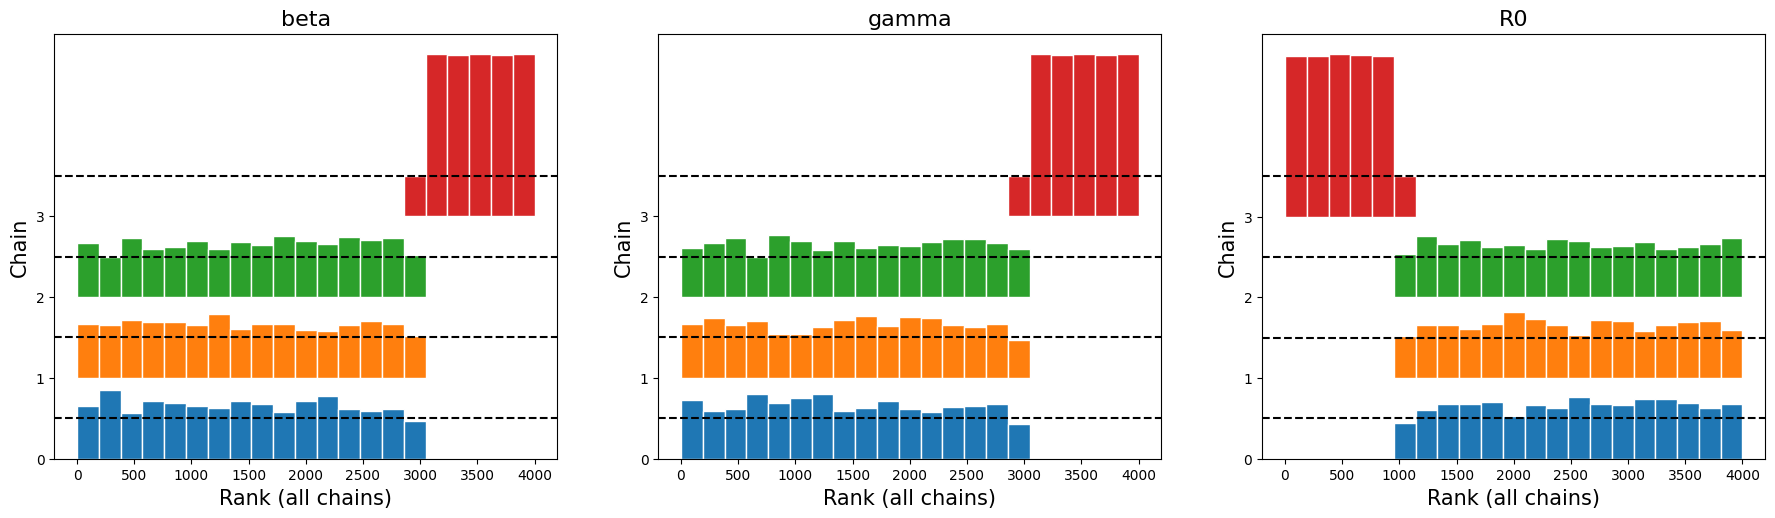

In [112]:
az.plot_rank(idata, var_names=["beta","gamma","R0"]); plt.show()

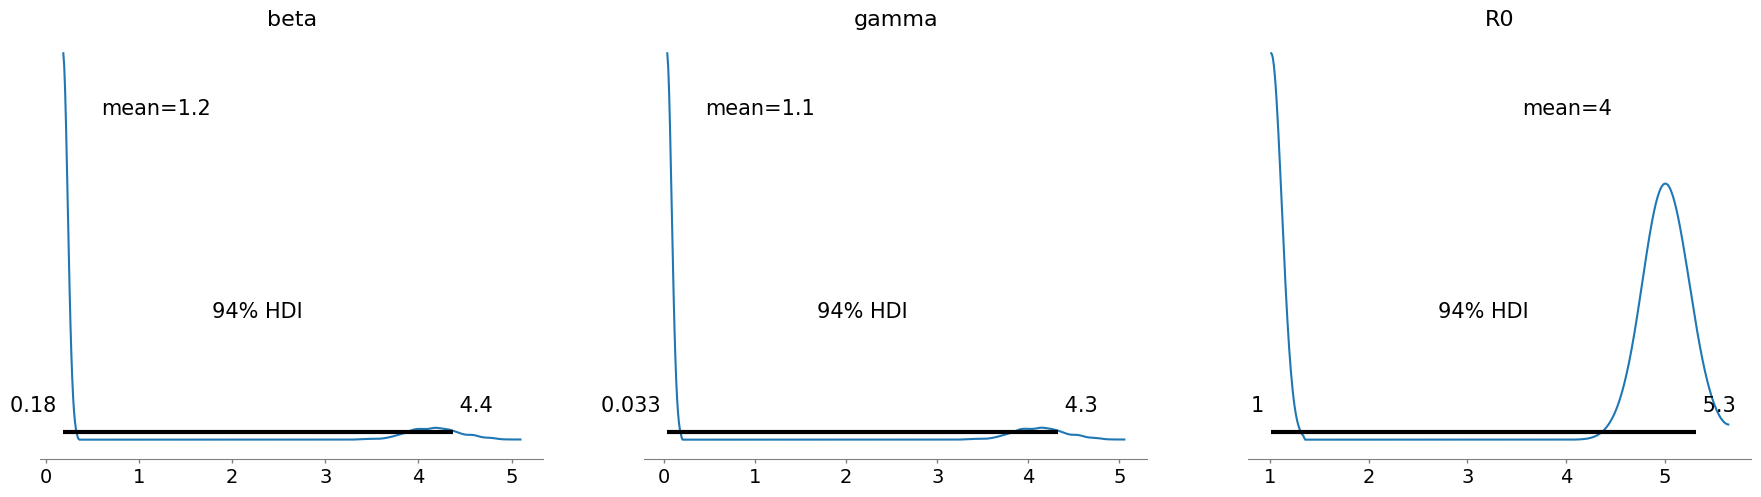

In [113]:
az.plot_posterior(idata, var_names=["beta","gamma","R0"]); plt.show()

In [114]:
# Calculate WAIC
waic = az.waic(idata)
print("\nWAIC:")
print(waic)



WAIC:
Computed from 4000 posterior samples and 253 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -2015.28    36.57
p_waic       66.83        -

There has been a warning during the calculation. Please check the results.


/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


In [115]:
# Calculate LOO
loo = az.loo(idata)
print("\nLOO:")
print(loo)


LOO:
Computed from 4000 posterior samples and 253 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2010.74    36.15
p_loo       62.29        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      253  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



In [101]:
stan_file_path = "sir_underreporting.stan"
with open(stan_file_path, 'r') as f:
    stan_code = f.read()


print(stan_code)

functions {
  array[] real sir(real t, array[] real y, array[] real theta, 
              array[] real x_r, array[] int x_i) {

      real S = y[1];
      real I = y[2];
      real R = y[3];
      int N = x_i[1];
      
      real beta = theta[1];
      real gamma = theta[2];
      
      real dS_dt = -beta * I * S / N;
      real dI_dt = beta * I * S / N - gamma * I;
      real dR_dt =  gamma * I;
      
      return {dS_dt, dI_dt, dR_dt};
  }
}
data {
  int<lower=1> n_days;
  real t0;
  array[3] real y0;
  array[n_days] real ts;
  int N;
  array[n_days] int cases;
}
transformed data {
  array[0] real x_r;
  array[1] int x_i = { N };
}
parameters {
  real<lower=0> gamma;
  real<lower=0> beta;
  real<lower=0> phi_inv;
  real<lower=0, upper=1> p_reported; // proportion of infected (symptomatic) people reported
}
transformed parameters{
  array[n_days, 3] real y;
  array [n_days - 1] real incidence;
  real phi = 1. / phi_inv;
  // initial compartement values
  array[2] real theta = {beta

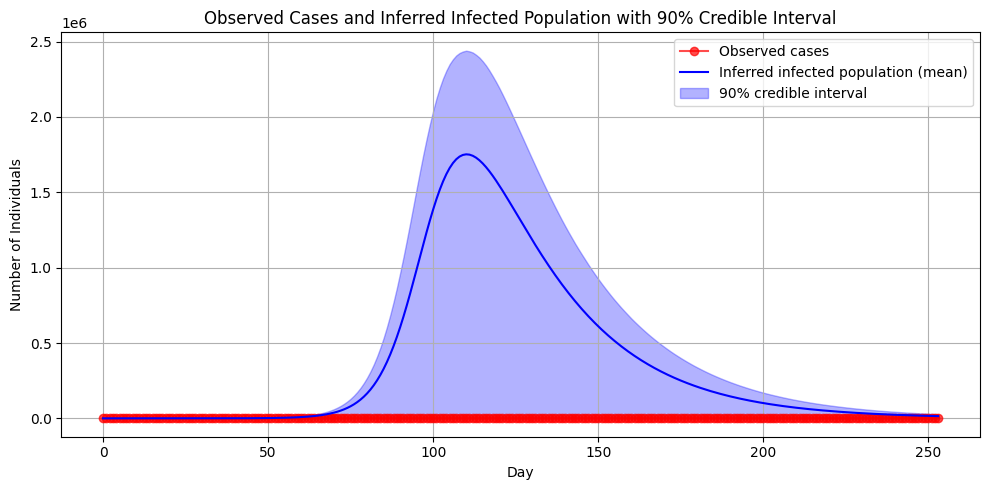

In [117]:
# ----------------------------------------
# 1. Extract posterior samples of I_t (Infected Population)
# ----------------------------------------

# Thin to reduce memory load if needed (optional)
# idata_thin = idata.sel(draw=slice(None, None, 10))

I_t_samples = idata.posterior["y"].sel(y_dim_1=1).stack(sample=("chain", "draw")).values # shape: [n_days, samples]

# ----------------------------------------
# 2. Compute Posterior Mean and 90% HDI
# ----------------------------------------
# Now I_t_samples is a 2D numpy array (n_days, samples)
I_t_mean = np.mean(I_t_samples, axis=1)
I_t_lower = np.percentile(I_t_samples, 5, axis=1)
I_t_upper = np.percentile(I_t_samples, 95, axis=1)

# ----------------------------------------
# 3. Plot Observed vs Inferred Infections
# ----------------------------------------

# Create a time axis with length n_days
days = np.arange(len(I_t_mean)) # This will now be of length n_days

plt.figure(figsize=(10, 5))
# Plot observed cases
plt.plot(days, df["daycount"], 'o-', label="Observed cases", color='red', alpha=0.7) # Use df["daycount"] which has length n_days

# Plot inferred infections (mean and credible interval)
plt.plot(days, I_t_mean, label="Inferred infected population (mean)", color='blue')
plt.fill_between(days, I_t_lower, I_t_upper, color='blue', alpha=0.3, label="90% credible interval")

plt.xlabel("Day")
plt.ylabel("Number of Individuals")
plt.title("Observed Cases and Inferred Infected Population with 90% Credible Interval")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('iemag6.png')
plt.savefig('iemag6.pdf')
plt.show()

Add reporting

In [ ]:
# --- Paths ---
#os.chdir
csv_path = Path("case_data_IRL_shorter.csv")
stan_path = Path("sir_incidence3.stan")

In [ ]:
# --- Load data ---
df = pd.read_csv(csv_path)

In [ ]:
cases = df["daycount"].astype(int).to_numpy()
n_days = len(cases)

In [ ]:
# --- Time axis used by Stan ODE block ---
t0 = 0.0
# Typical choice: one time unit per row. Stan expects strictly increasing ts:
ts = np.arange(1, n_days + 1, dtype=float)

In [ ]:
# --- Population size (N)---
N = 4900000

In [ ]:
# Initial conditions [S0, I0, R0]; common choice starts with 1 infected, 0 recovered.
y0 = np.array([N - 1, 1, 0], dtype=float)

In [ ]:
# --- Build Stan data list (must match the Stan file's data block) ---
stan_data = {
    "n_days": int(n_days),
    "y0": y0.astype(float),
    "t0": float(t0),
    "ts": ts.astype(float),
    "N": int(N),
    "cases": cases.astype(int),
}

In [ ]:
model = CmdStanModel(stan_file="sir_incidence3.stan",
                     compile="stan --build=make TBB=true")
fit5 = model.sample(data=stan_data, seed=123,adapt_delta=0.95, max_treedepth=12, iter_warmup=1500)

If you wish to force recompilation, use force_compile=True instead.


chain 1:   0%|          | 0/2500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2500 [00:00<?, ?it/s, (Warmup)]

Exception: neg_binomial_2_lpmf: Location parameter[9] is -2.54251e-07, but must be positive finite! (in 'sir_incidence3.stan', line 60, column 2 to column 55)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence3.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence3.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence3.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence3.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence3.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence3.stan

In [ ]:
print(fit5.diagnose())

Processing csv files: /tmp/tmpif3afz9p/sir_incidence3zgvtye7z/sir_incidence3-20251109013328_1.csv, /tmp/tmpif3afz9p/sir_incidence3zgvtye7z/sir_incidence3-20251109013328_2.csv, /tmp/tmpif3afz9p/sir_incidence3zgvtye7z/sir_incidence3-20251109013328_3.csv, /tmp/tmpif3afz9p/sir_incidence3zgvtye7z/sir_incidence3-20251109013328_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
The E-BFMI, 0.01, is below the nominal threshold of 0.30 which suggests that HMC may have trouble exploring the target distribution.
If possible, try to reparameterize the model.

The following parameters had fewer than 0.001 effective draws per transition:
  gamma, beta, phi_inv, y[9,1], y[16,1], y[19,1], y[20,1], y[21,1], y[22,1], y[23,1], y[24,1], y[25,1], y[26,1], y[27,1], y[28,1], y[29,1], y[30,1], y[31,1], y[32,1], y[33,1], y[34,1], y[3

In [ ]:
fit5.summary()

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
lp__,-1.970370e+03,24.403600,34.580200,-2.031110e+03,-1.950640e+03,-1.949140e+03,2.00793,0.001162,30.74260
gamma,3.204300e+00,1.293550,1.846920,3.636630e-02,4.127600e+00,4.714700e+00,2.03860,0.001180,7.55117
beta,3.278020e+00,1.260090,1.799780,1.917940e-01,4.174300e+00,4.758430e+00,2.04003,0.001181,7.39380
phi_inv,5.514890e+00,0.675660,1.006870,4.519130e+00,5.093370e+00,7.526360e+00,2.22071,0.001286,3.06678
"y[1,1]",5.899993e+06,0.103971,4.649710,5.899990e+06,5.899990e+06,5.900000e+06,2000.00000,1.157850,1.99960
...,...,...,...,...,...,...,...,...,...
log_lik[249],-9.291150e+00,0.352868,0.525280,-1.032530e+01,-9.070390e+00,-8.770360e+00,2.21594,0.001283,3.06619
log_lik[250],-8.497040e+00,0.268097,0.394708,-9.266070e+00,-8.323450e+00,-8.120360e+00,2.16754,0.001255,3.45074
log_lik[251],-9.600300e+00,0.390485,0.587143,-1.075290e+01,-9.364820e+00,-8.999210e+00,2.26089,0.001309,2.81545
log_lik[252],-8.163900e+00,0.239128,0.351444,-8.845830e+00,-8.008750e+00,-7.830020e+00,2.15999,0.001250,3.53239


In [ ]:
idata = az.from_cmdstanpy(posterior=fit5)

# Summary incl. mean, sd, mcse, r_hat, ess_bulk/tail
print(az.summary(idata, var_names=["beta","gamma","R0","phi_inv"], round_to=3))

          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta     3.278  1.800   0.187    4.728      0.888    0.502     7.345   
gamma    3.204  1.847   0.032    4.684      0.911    0.515     7.306   
R0       2.033  1.775   1.008    5.271      0.882    0.512     7.288   
phi_inv  5.515  1.007   4.324    7.539      0.473    0.268     7.287   

         ess_tail  r_hat  
beta       30.359  1.532  
gamma      30.658  1.532  
R0         31.516  1.532  
phi_inv    28.902  1.532  


In [ ]:
# Convert your CmdStanPy fit to InferenceData
idata = az.from_cmdstanpy(posterior=fit5)

# See what sampler stats are present
print("sample_stats vars:", list(idata.sample_stats.data_vars))

# Divergences
div = idata.sample_stats["diverging"]
n_div = int(div.sum())
print("Divergences:", n_div)

# Tree depth (ArviZ name is 'tree_depth')
if "tree_depth" in idata.sample_stats:
    td = idata.sample_stats["tree_depth"]
    max_td = int(td.max())
    n_max_td = int((td == max_td).sum())
    print(f"Hits at max tree depth ({max_td}):", n_max_td)
else:
    print("No 'tree_depth' in sample_stats (backend/version mismatch?).")

# BFMI (energy diagnostic; <~0.3 can be concerning)
bfmi_values = az.bfmi(idata)
if np.isscalar(bfmi_values):
    print("BFMI:", float(bfmi_values))
else:
    print("Mean BFMI:", float(np.mean(bfmi_values)))

# Step size & acceptance rate
if "step_size" in idata.sample_stats:
    print("Mean step_size:", float(idata.sample_stats["step_size"].mean()))
else:
    print("No 'step_size' in sample_stats.")

# ArviZ uses 'acceptance_rate' for Stan backends
if "acceptance_rate" in idata.sample_stats:
    print("Mean acceptance_rate:", float(idata.sample_stats["acceptance_rate"].mean()))
else:
    print("No 'acceptance_rate' in sample_stats.")

sample_stats vars: ['acceptance_rate', 'diverging', 'energy', 'lp', 'n_steps', 'step_size', 'tree_depth']
Divergences: 0
Hits at max tree depth (11): 583
Mean BFMI: 1.1003587877099337
Mean step_size: 0.12831926750000391
Mean acceptance_rate: 0.9481760587499988


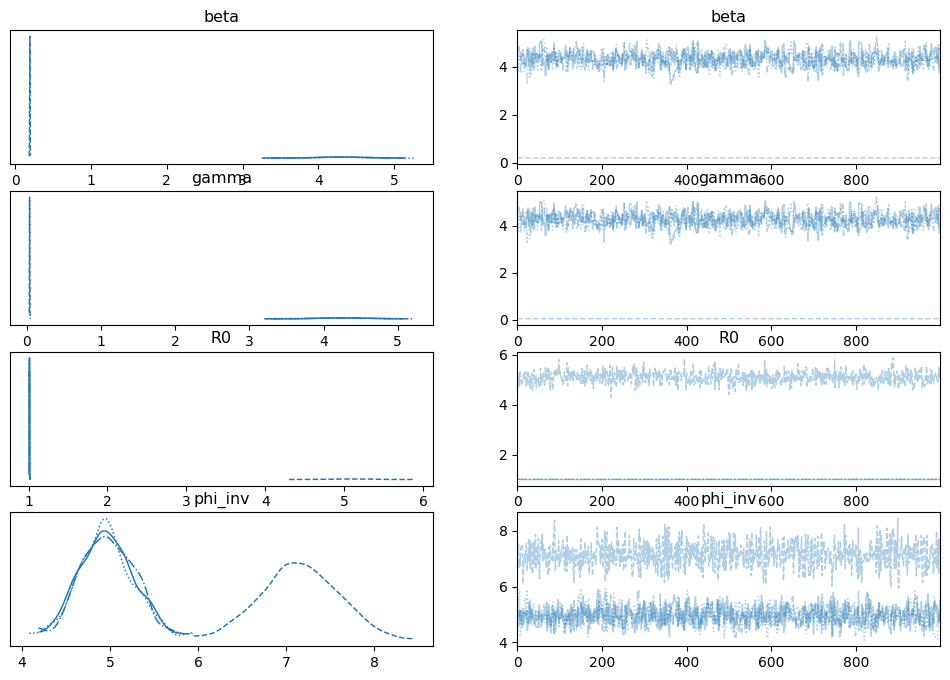

In [ ]:
az.plot_trace(idata, var_names=["beta","gamma","R0","phi_inv"]); plt.show()

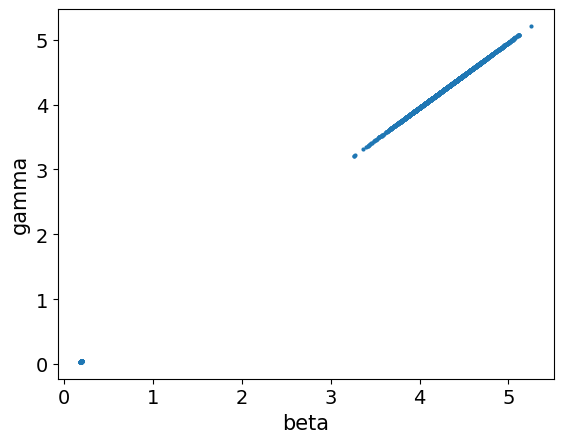

In [ ]:
az.plot_pair(idata, var_names=["beta","gamma"], kind="scatter", divergences=True); plt.show()

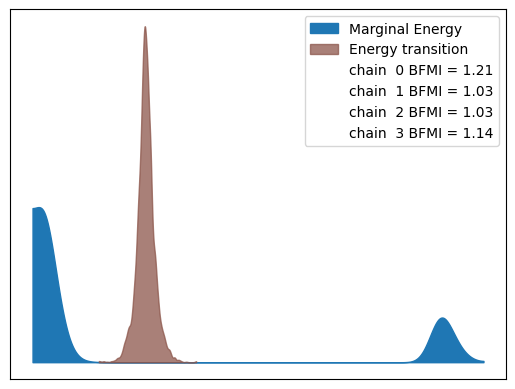

In [ ]:
az.plot_energy(idata); plt.show()

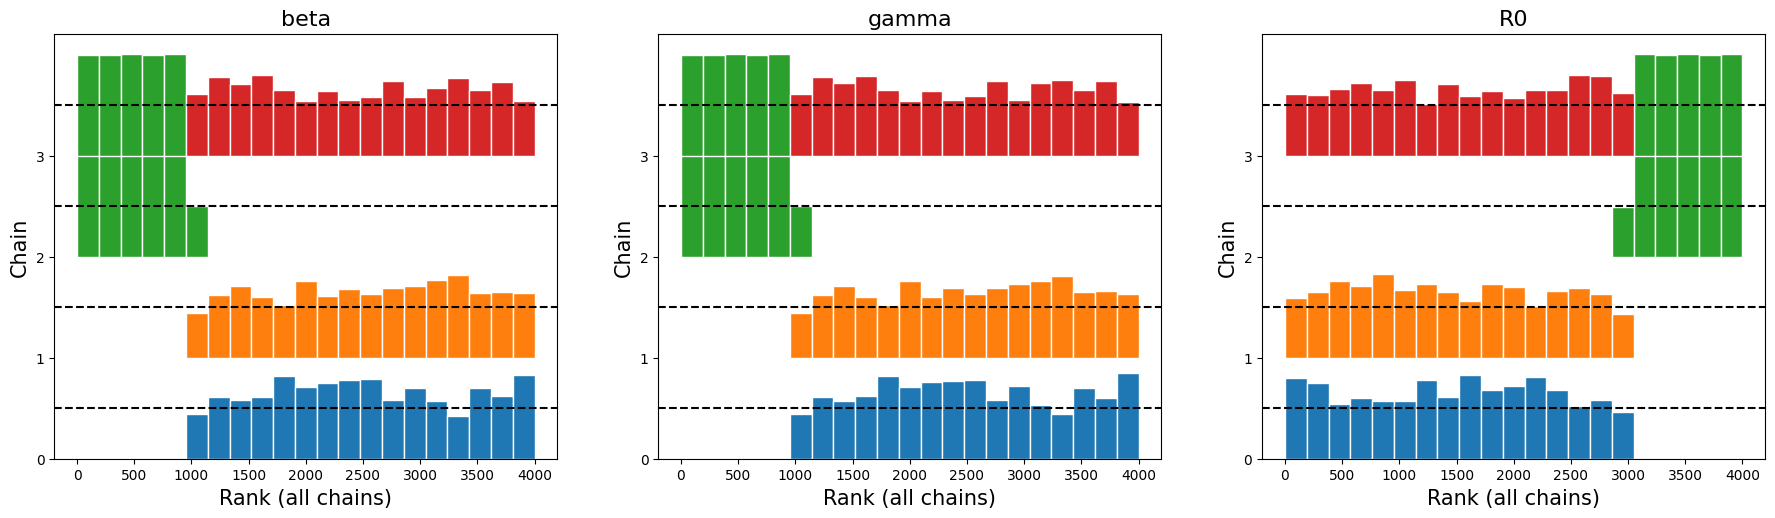

In [ ]:
az.plot_rank(idata, var_names=["beta","gamma","R0"]); plt.show()

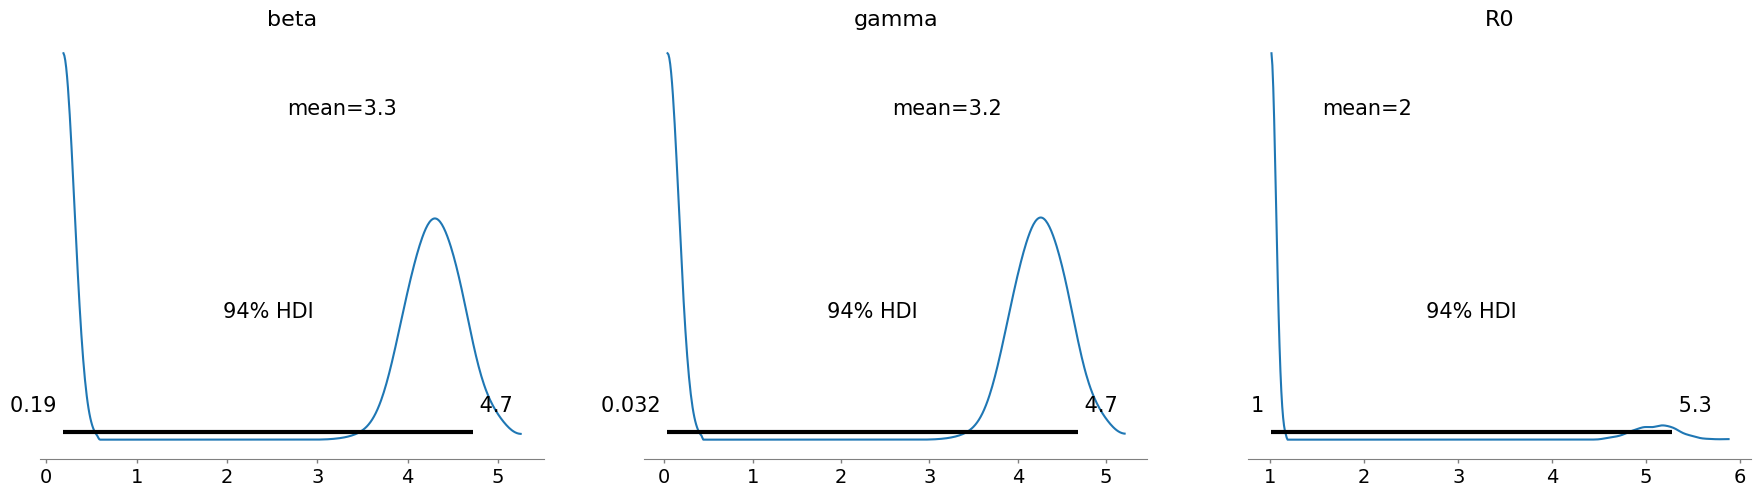

In [ ]:
az.plot_posterior(idata, var_names=["beta","gamma","R0"]); plt.show()

In [ ]:
# Calculate WAIC
waic = az.waic(idata)
print("\nWAIC:")
print(waic)



WAIC:
Computed from 4000 posterior samples and 253 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -1955.14    37.25
p_waic       64.12        -

There has been a warning during the calculation. Please check the results.


/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


In [ ]:
# Calculate LOO
loo = az.loo(idata)
print("\nLOO:")
print(loo)


LOO:
Computed from 4000 posterior samples and 253 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1951.10    36.87
p_loo       60.08        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      253  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



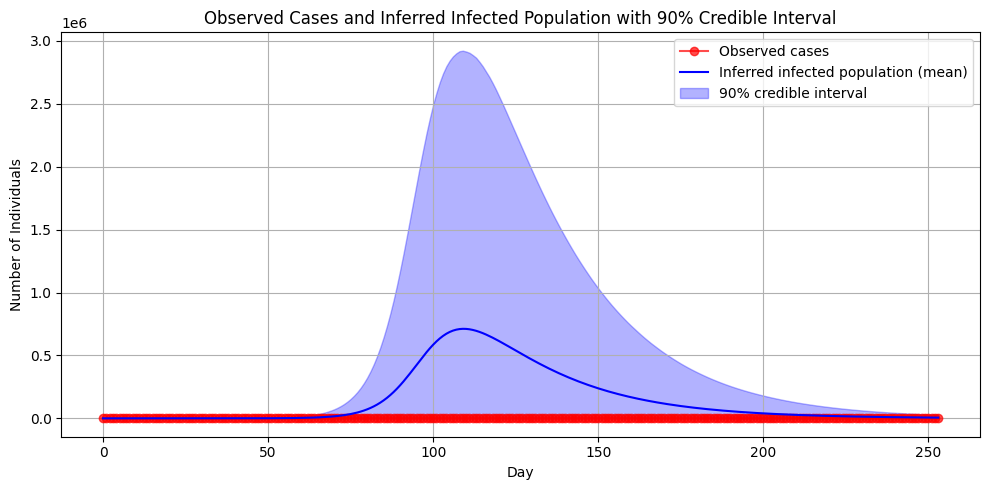

In [ ]:
# ----------------------------------------
# 1. Extract posterior samples of I_t (Infected Population)
# ----------------------------------------

# Thin to reduce memory load if needed (optional)
# idata_thin = idata.sel(draw=slice(None, None, 10))

I_t_samples = idata.posterior["y"].sel(y_dim_1=1).stack(sample=("chain", "draw")).values # shape: [n_days, samples]

# ----------------------------------------
# 2. Compute Posterior Mean and 90% HDI
# ----------------------------------------
# Now I_t_samples is a 2D numpy array (n_days, samples)
I_t_mean = np.mean(I_t_samples, axis=1)
I_t_lower = np.percentile(I_t_samples, 5, axis=1)
I_t_upper = np.percentile(I_t_samples, 95, axis=1)

# ----------------------------------------
# 3. Plot Observed vs Inferred Infections
# ----------------------------------------

# Create a time axis with length n_days
days = np.arange(len(I_t_mean)) # This will now be of length n_days

plt.figure(figsize=(10, 5))
# Plot observed cases
plt.plot(days, df["daycount"], 'o-', label="Observed cases", color='red', alpha=0.7) # Use df["daycount"] which has length n_days

# Plot inferred infections (mean and credible interval)
plt.plot(days, I_t_mean, label="Inferred infected population (mean)", color='blue')
plt.fill_between(days, I_t_lower, I_t_upper, color='blue', alpha=0.3, label="90% credible interval")

plt.xlabel("Day")
plt.ylabel("Number of Individuals")
plt.title("Observed Cases and Inferred Infected Population with 90% Credible Interval")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('iemag5.png')
plt.savefig('iemag5.pdf')
plt.show()

## Irish data - First 3 months only

In [12]:
os.chdir('/content/WSL/')

In [10]:
# --- Paths ---
#os.chdir
csv_path = Path("case_data_IRL_shorter.csv")
stan_path = Path("sir_incidence3.stan")

In [13]:
# --- Load data ---
df = pd.read_csv(csv_path)

In [14]:
cases = df["daycount"].astype(int).to_numpy()
n_days = len(cases)

In [15]:
# --- Time axis used by Stan ODE block ---
t0 = 0.0
# Typical choice: one time unit per row. Stan expects strictly increasing ts:
ts = np.arange(1, n_days + 1, dtype=float)

In [16]:
# --- Population size (N)---
N = 4900000

In [17]:
# Initial conditions [S0, I0, R0]; common choice starts with 1 infected, 0 recovered.
y0 = np.array([N - 1, 1, 0], dtype=float)

In [18]:
# --- Build Stan data list (must match the Stan file's data block) ---
stan_data = {
    "n_days": int(n_days),
    "y0": y0.astype(float),
    "t0": float(t0),
    "ts": ts.astype(float),
    "N": int(N),
    "cases": cases.astype(int),
}

In [26]:
model6 = CmdStanModel(stan_file="sir_incidence3.stan",
                     compile="stan --build=make TBB=true")
fit6 = model6.sample(data=stan_data, seed=123)

If you wish to force recompilation, use force_compile=True instead.


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

Exception: neg_binomial_2_lpmf: Location parameter[9] is -2.54251e-07, but must be positive finite! (in 'sir_incidence3.stan', line 60, column 2 to column 55)
	Exception: integrate_ode_rk45: ode parameters and data[1] is inf, but must be finite! (in 'sir_incidence3.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[1] is inf, but must be finite! (in 'sir_incidence3.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[1] is inf, but must be finite! (in 'sir_incidence3.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[1] is inf, but must be finite! (in 'sir_incidence3.stan', line 46, column 4 to column 61)
	Exception: neg_binomial_2_lpmf: Location parameter[1] is -nan, but must be positive finite! (in 'sir_incidence3.stan', line 60, column 2 to column 55)
	Exception: neg_binomial_2_lpmf: Location parameter[1] is -nan, but must be positive finite! (in 'sir_inc

	Chain 1 had 107 divergent transitions (10.7%)
	Chain 2 had 12 divergent transitions (1.2%)
	Chain 3 had 300 divergent transitions (30.0%)
	Chain 4 had 260 divergent transitions (26.0%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [27]:
print(fit6.diagnose())

Processing csv files: /tmp/tmpf0t5715p/sir_incidence3ypt37wyu/sir_incidence3-20251111021216_1.csv, /tmp/tmpf0t5715p/sir_incidence3ypt37wyu/sir_incidence3-20251111021216_2.csv, /tmp/tmpf0t5715p/sir_incidence3ypt37wyu/sir_incidence3-20251111021216_3.csv, /tmp/tmpf0t5715p/sir_incidence3ypt37wyu/sir_incidence3-20251111021216_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
680 of 4000 (17.00%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Effective sample size satisfactory.

The following parameters had split R-hat greater than 1.05:
  gamma, beta, phi_inv, y[5,1], y[6,1], y[7,1], y[8,1], y[9,1], y[10,1], y[11,1], y[1

In [28]:
fit6.summary()

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
lp__,-4.280120e+02,0.258413,1.810330,-4.320260e+02,-4.274960e+02,-4.262730e+02,49.0779,0.299943,1.07411
gamma,1.973930e+00,0.092071,0.561790,1.064720e+00,2.020920e+00,2.682660e+00,37.2310,0.227540,1.09690
beta,2.331770e+00,0.073832,0.469745,1.534670e+00,2.379530e+00,2.934800e+00,40.4792,0.247391,1.08685
phi_inv,2.216390e+00,0.060857,0.327832,1.703630e+00,2.198850e+00,2.818900e+00,29.0187,0.177350,1.07274
"y[1,1]",4.900000e+06,NaN,0.353377,4.900000e+06,4.900000e+06,4.900000e+06,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
log_lik[48],-8.231150e+00,0.106134,0.779685,-9.403500e+00,-7.765190e+00,-7.436470e+00,53.9673,0.329825,1.08859
log_lik[49],-8.143560e+00,0.111016,0.811167,-9.353450e+00,-7.637350e+00,-7.333480e+00,53.3885,0.326288,1.09011
log_lik[50],-8.135290e+00,0.110599,0.807118,-9.340710e+00,-7.628730e+00,-7.333720e+00,53.2567,0.325482,1.09098
log_lik[51],-8.242980e+00,0.106295,0.755070,-9.360170e+00,-7.846900e+00,-7.429830e+00,50.4604,0.308392,1.08812


In [29]:
idata = az.from_cmdstanpy(posterior=fit6)

# Summary incl. mean, sd, mcse, r_hat, ess_bulk/tail
print(az.summary(idata, var_names=["beta","gamma","R0","phi_inv"], round_to=3))

          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta     2.332  0.470   1.527    3.147      0.074    0.109    56.276   
gamma    1.974  0.562   1.068    2.942      0.092    0.140    51.545   
R0       1.352  0.888   1.057    1.399      0.218    0.557    47.992   
phi_inv  2.216  0.328   1.615    2.836      0.046    0.014    40.672   

         ess_tail  r_hat  
beta       18.198  1.082  
gamma      18.451  1.081  
R0         18.195  1.079  
phi_inv   128.764  1.086  


In [39]:
idata

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats

In [30]:
# Convert your CmdStanPy fit to InferenceData
idata = az.from_cmdstanpy(posterior=fit6)

# See what sampler stats are present
print("sample_stats vars:", list(idata.sample_stats.data_vars))

# Divergences
div = idata.sample_stats["diverging"]
n_div = int(div.sum())
print("Divergences:", n_div)

# Tree depth (ArviZ name is 'tree_depth')
if "tree_depth" in idata.sample_stats:
    td = idata.sample_stats["tree_depth"]
    max_td = int(td.max())
    n_max_td = int((td == max_td).sum())
    print(f"Hits at max tree depth ({max_td}):", n_max_td)
else:
    print("No 'tree_depth' in sample_stats (backend/version mismatch?).")

# BFMI (energy diagnostic; <~0.3 can be concerning)
bfmi_values = az.bfmi(idata)
if np.isscalar(bfmi_values):
    print("BFMI:", float(bfmi_values))
else:
    print("Mean BFMI:", float(np.mean(bfmi_values)))

# Step size & acceptance rate
if "step_size" in idata.sample_stats:
    print("Mean step_size:", float(idata.sample_stats["step_size"].mean()))
else:
    print("No 'step_size' in sample_stats.")

# ArviZ uses 'acceptance_rate' for Stan backends
if "acceptance_rate" in idata.sample_stats:
    print("Mean acceptance_rate:", float(idata.sample_stats["acceptance_rate"].mean()))
else:
    print("No 'acceptance_rate' in sample_stats.")

sample_stats vars: ['acceptance_rate', 'diverging', 'energy', 'lp', 'n_steps', 'step_size', 'tree_depth']
Divergences: 680
Hits at max tree depth (9): 3
Mean BFMI: 0.8219099032327535
Mean step_size: 0.015401255000000611
Mean acceptance_rate: 0.7265241549190125


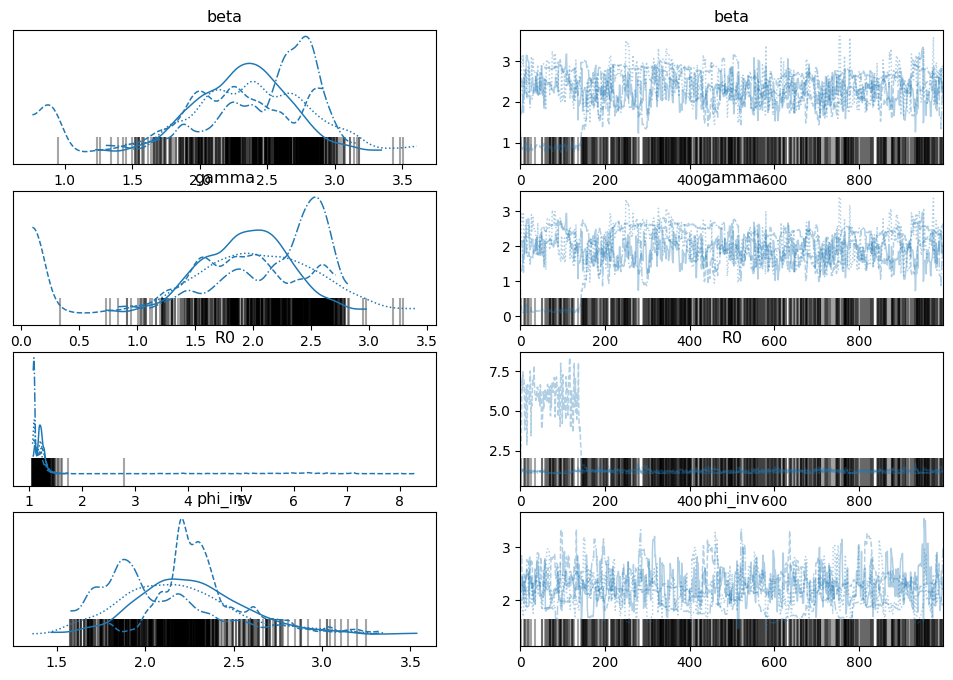

In [31]:
az.plot_trace(idata, var_names=["beta","gamma","R0","phi_inv"]); plt.show()

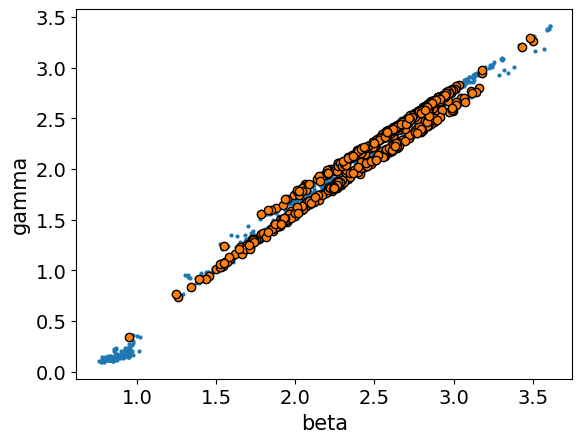

In [32]:
az.plot_pair(idata, var_names=["beta","gamma"], kind="scatter", divergences=True); plt.show()

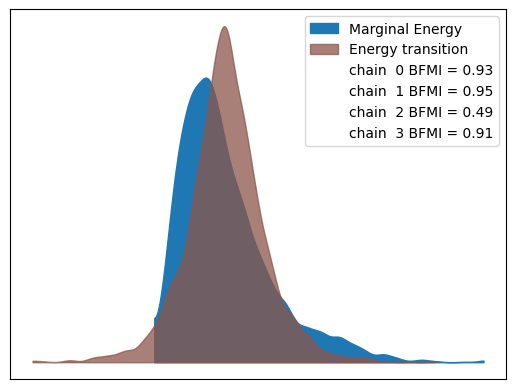

In [33]:
az.plot_energy(idata); plt.show()

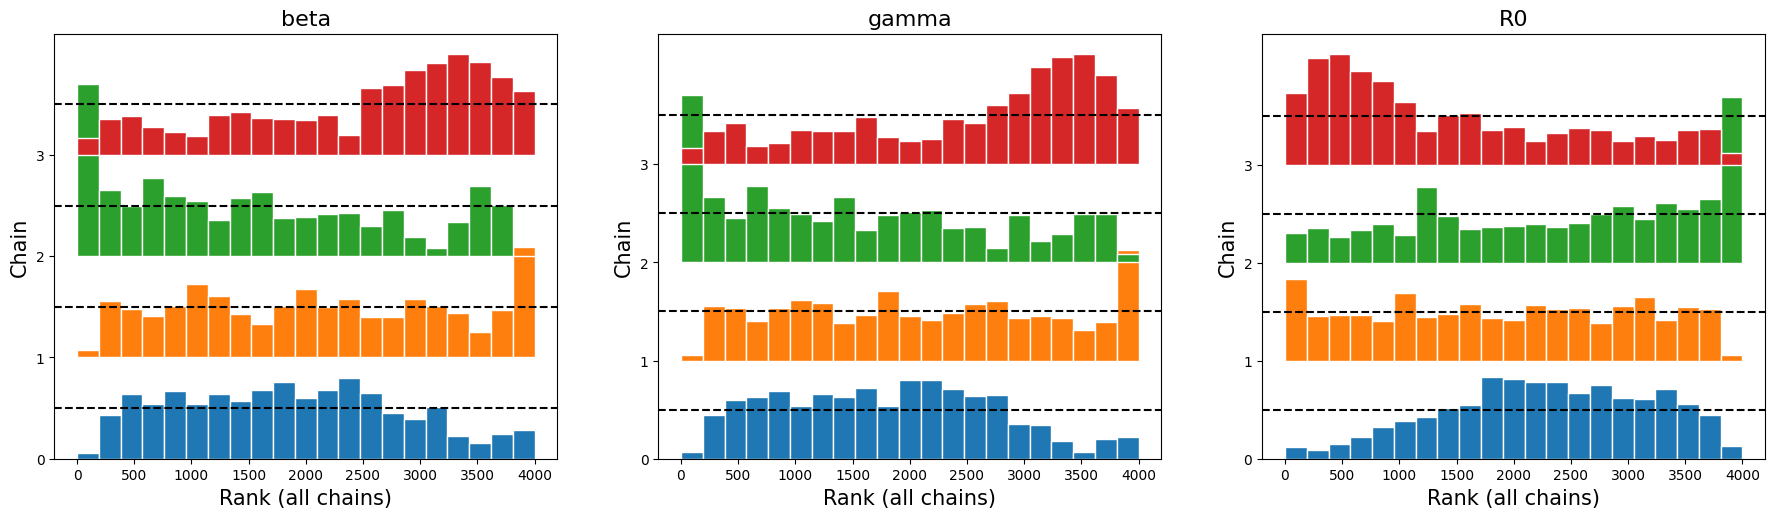

In [34]:
az.plot_rank(idata, var_names=["beta","gamma","R0"]); plt.show()

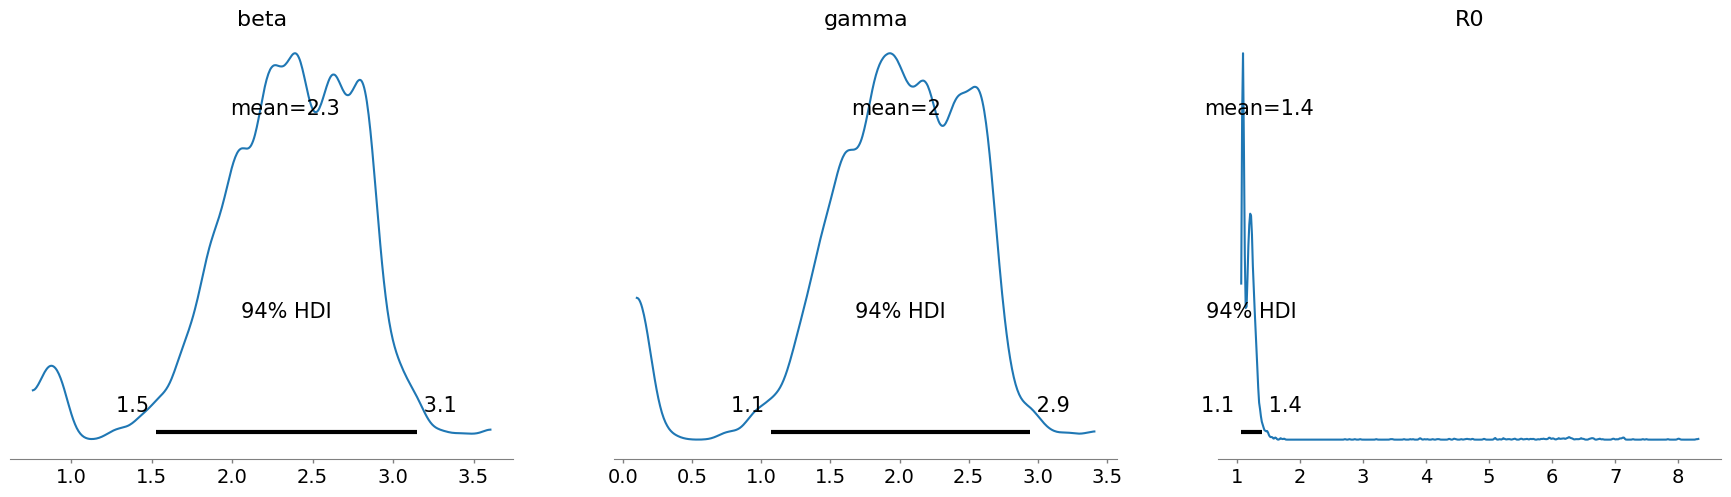

In [35]:
az.plot_posterior(idata, var_names=["beta","gamma","R0"]); plt.show()

In [36]:
# Calculate WAIC
waic = az.waic(idata)
print("\nWAIC:")
print(waic)



WAIC:
Computed from 4000 posterior samples and 52 observations log-likelihood matrix.

          Estimate       SE
elpd_waic  -423.36    10.30
p_waic       18.57        -

There has been a warning during the calculation. Please check the results.


/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


In [37]:
# Calculate LOO
loo = az.loo(idata)
print("\nLOO:")
print(loo)


LOO:
Computed from 4000 posterior samples and 52 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -422.37    10.21
p_loo       17.58        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       44   84.6%
   (0.70, 1]   (bad)         4    7.7%
   (1, Inf)   (very bad)    4    7.7%



/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [52]:
idata.posterior['incidence'][0][0].shape

(52,)

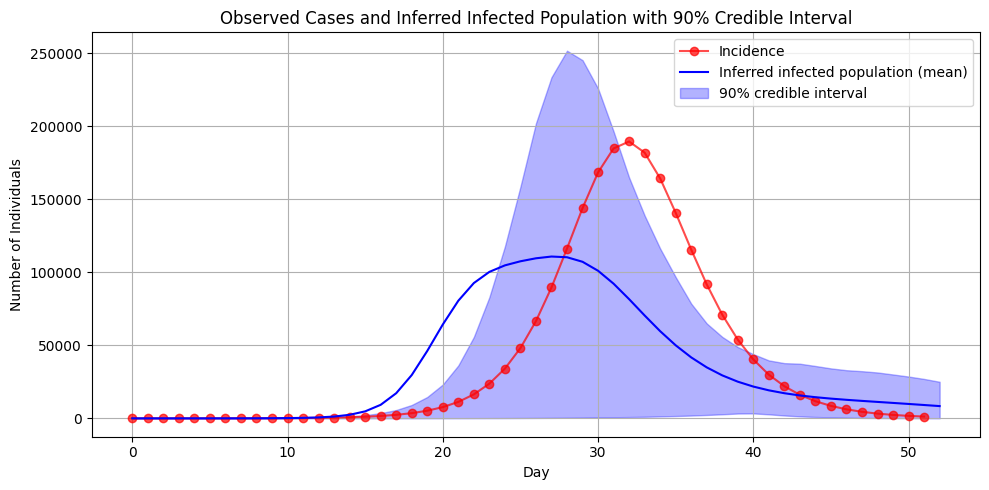

In [53]:
# ----------------------------------------
# 1. Extract posterior samples of I_t (Infected Population)
# ----------------------------------------

# Thin to reduce memory load if needed (optional)
# idata_thin = idata.sel(draw=slice(None, None, 10))

I_t_samples = idata.posterior["y"].sel(y_dim_1=1).stack(sample=("chain", "draw")).values # shape: [n_days, samples]

# ----------------------------------------
# 2. Compute Posterior Mean and 90% HDI
# ----------------------------------------
# Now I_t_samples is a 2D numpy array (n_days, samples)
I_t_mean = np.mean(I_t_samples, axis=1)
I_t_lower = np.percentile(I_t_samples, 5, axis=1)
I_t_upper = np.percentile(I_t_samples, 95, axis=1)

# ----------------------------------------
# 3. Plot Observed vs Inferred Infections
# ----------------------------------------

# Create a time axis with length n_days
days = np.arange(len(I_t_mean)) # This will now be of length n_days

plt.figure(figsize=(10, 5))
# Plot observed cases
plt.plot(days, df["daycount"], 'o-', label="Observed cases", color='red', alpha=0.7) # Use df["daycount"] which has length n_days

#plt.plot(days[:-1], idata.posterior['incidence'][0][0],'o-', label="Incidence", color='red', alpha=0.7)

# Plot inferred infections (mean and credible interval)
plt.plot(days, I_t_mean, label="Inferred infected population (mean)", color='blue')
plt.fill_between(days, I_t_lower, I_t_upper, color='blue', alpha=0.3, label="90% credible interval")

plt.xlabel("Day")
plt.ylabel("Number of Individuals")
plt.title("Observed Cases and Inferred Infected Population with 90% Credible Interval")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('iemag5.png')
plt.savefig('iemag5.pdf')
plt.show()

Add reporting